In [604]:
library(phyloseq)
library(igraph)
library(ggplot2)
library(dplyr)
library(svglite)
library(tidyverse)
library(viridis)

In [605]:
theme_glab <- function(base_size = 11,
                    base_family = "",
                    base_line_size = base_size / 180,
                    base_rect_size = base_size / 180) {
   
    font <- "Helvetica" #assign font family up front
   
    theme_bw(base_size = base_size,
                base_family = base_family,
                base_line_size = base_line_size) %+replace%
    theme(
        legend.background =  element_blank(),
        legend.title =       element_text(color = rgb(100, 100, 100, maxColorValue = 255),
                                          size = rel(0.65),
                                         hjust = 0),
        legend.text =        element_text(color = rgb(100, 100, 100, maxColorValue = 255),
                                          size = rel(0.65)),
        legend.key.size =    unit(0.8, "lines"),
     
      plot.title = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0),
       
      axis.title = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)),
      axis.text = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)),
       
      plot.caption = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.35),
        hjust = 1),
       
      panel.grid.major = element_blank(),  
      panel.grid.minor = element_blank(),  
      panel.border = element_rect(fill = NA, colour = rgb(100, 100, 100, maxColorValue = 255)),

     
      complete = TRUE
    )
}

In [606]:
set.seed(10000)
options(repr.plot.width=12, repr.plot.height=8)

In [607]:
env_df  <- read.csv('../data_processed/sample_table.csv', row.names=1, check.names=FALSE)
otu_mat <- read.csv('../data_processed/otu_intersect_bp.csv', row.names=1, check.names=FALSE)
tax_mat <- as.matrix(read.csv('../data_processed/tax.csv', row.names=1, check.names=FALSE))

In [608]:
get_rpoB_total <- function(df) {
  df[] <- lapply(df, as.numeric)
  colSums(df[c("K03043","K13797"), , drop=FALSE], na.rm=TRUE) +
    colMeans(df[c("K03044","K03045"), , drop=FALSE], na.rm=TRUE) +
    as.numeric(df["K13798", , drop=TRUE])
}

In [609]:
rpob <- get_rpoB_total(otu_mat)
rpob <- data.frame(rpob = rpob)

In [610]:
summary(rpob)
sum(rpob >= 500, na.rm = TRUE)
length(rpob >= 500)

# Percentage of samples above 500 rpoB counts
(sum(rpob >= 500, na.rm = TRUE)/length(rpob >= 500))*100

      rpob       
 Min.   :  4500  
 1st Qu.: 23000  
 Median : 35000  
 Mean   : 50887  
 3rd Qu.: 70250  
 Max.   :241500  

[1] 1513

[1] 1513

[1] 100

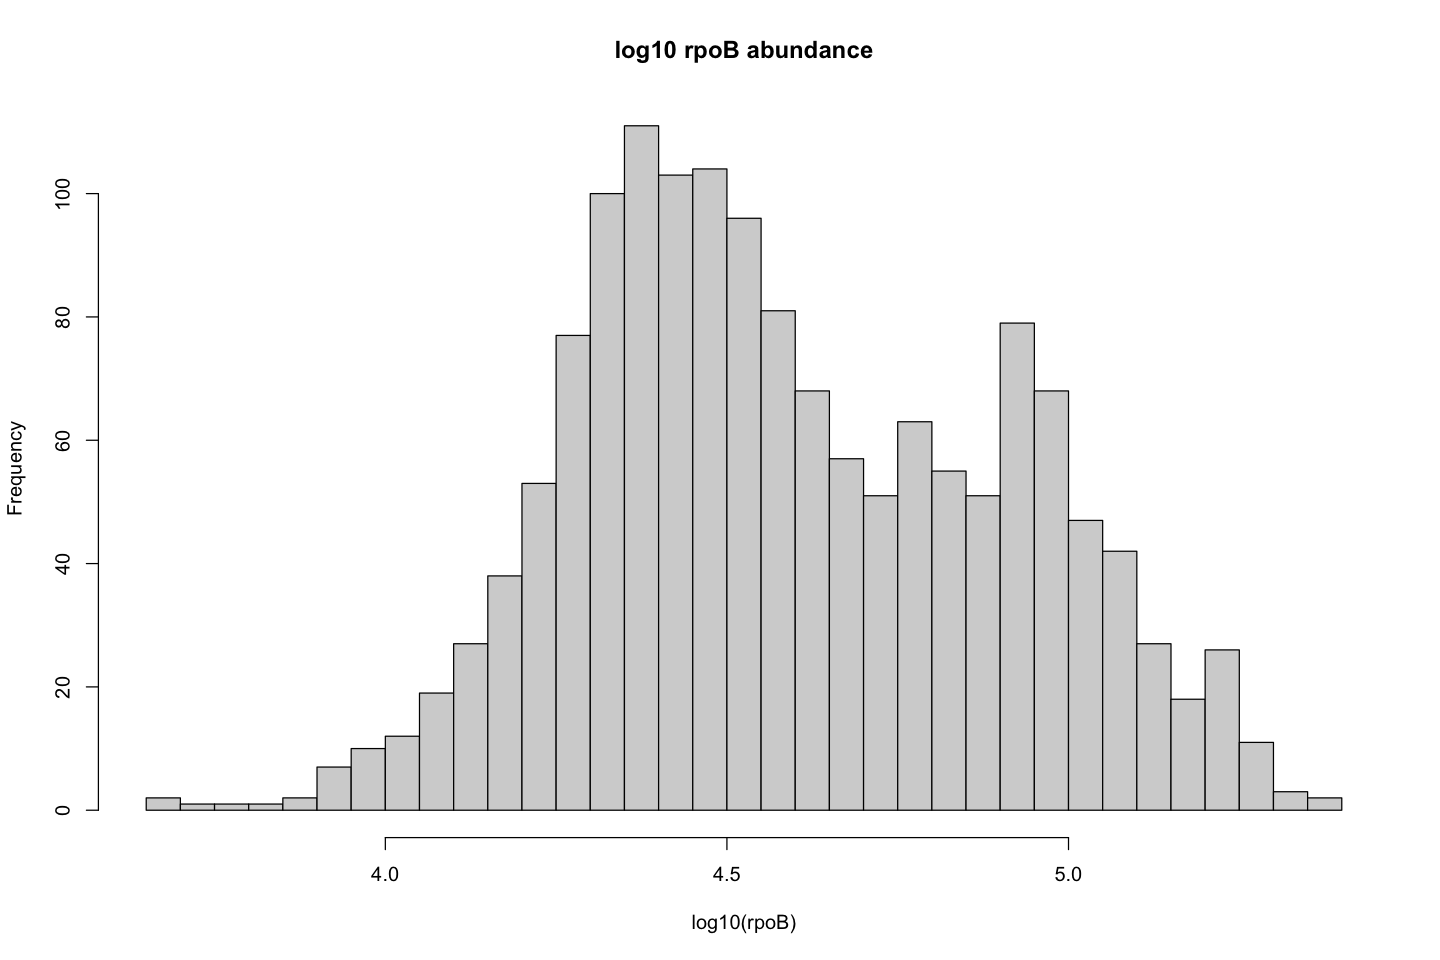

In [611]:
hist(as.numeric(log10(rpob[,1])), breaks = 50,
     main = "log10 rpoB abundance",
     xlab = "log10(rpoB)")

In [612]:
otu_rpo <- sweep(otu_mat, 2, get_rpoB_total(otu_mat), "/")
cat("otu_rpo:", nrow(otu_rpo), "rows,", ncol(otu_rpo), "samples\n")

otu_rpo: 13199 rows, 1513 samples


In [613]:
eps <- 0.1

otu_alr <- sweep(log10(otu_mat + eps), 2, log10(get_rpoB_total(otu_mat) + eps), FUN = "-")
cat("otu_alr:", nrow(otu_alr), "rows,", ncol(otu_alr), "samples\n") # print results for sanity check 

otu_alr: 13199 rows, 1513 samples


In [614]:
save.image()

In [615]:
phylo_rpo <- phyloseq(otu_table(otu_rpo, taxa_are_rows = TRUE), tax_table(tax_mat), sample_data(env_df))

In [616]:
phylo_rpo


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13199 taxa and 1513 samples ]
sample_data() Sample Data:       [ 1513 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13199 taxa by 49 taxonomic ranks ]

In [617]:
phylo_rpo_m <- as.matrix(otu_table(phylo_rpo))
phylo_rpo_m <- apply(phylo_rpo_m, 2, function(x) as.numeric(as.character(x)))
rownames(phylo_rpo_m) <- rownames(otu_table(phylo_rpo))
colnames(phylo_rpo_m) <- colnames(otu_table(phylo_rpo))

# genes that are zero in all samples
zero_genes <- rowSums(phylo_rpo_m != 0, na.rm = TRUE) == 0

# how many?
sum(zero_genes)

# Filter them out of phylo_rpo
keep_genes <- taxa_names(phylo_rpo)[!zero_genes] 
phylo_rpo <- prune_taxa(keep_genes, phylo_rpo)

# Inspect                     
phylo_rpo

[1] 102

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13097 taxa and 1513 samples ]
sample_data() Sample Data:       [ 1513 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13097 taxa by 49 taxonomic ranks ]

In [618]:
phylo_alr <- phyloseq(otu_table(otu_alr, taxa_are_rows = TRUE), tax_table(tax_mat), sample_data(env_df))

# Remove gene with all-zero abundances in the rpoB normalized objects to keep them with the same taxa
phylo_alr <- prune_taxa(keep_genes, phylo_alr)

# Inspect 
phylo_alr

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13097 taxa and 1513 samples ]
sample_data() Sample Data:       [ 1513 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13097 taxa by 49 taxonomic ranks ]

In [619]:
head(otu_table(phylo_rpo))
head(otu_table(phylo_alr))

,AC_220827_F,BO_220829_F,BP2_220829_F,BS_220902_F,CF_220902_F,FV_220827_F,GV_220827_F,HO_220830_F,LB_220827_F,OS_220831_F,⋯,SRR31704008,SRR32467810,SRR34018561,SRR34141452,SRR5234506,SRR5234509,SRR5916339,SRR7985596,SRR9924777,SRR9924779
K00001,0.098859316,0.062500000,0.032786885,0.128654971,0.072727273,0.09756098,0.069073783,0.07185629,0.08435852,0.114728682,⋯,0.092783505,0.14432990,0.2086957,0.05434783,0.25925926,0.197424893,0.2198953,0.047393365,0.090625,0.104430380
K00002,0.015209125,0.014705882,0.000000000,0.011695906,0.054545455,0.00000000,0.015698587,0.01796407,0.01054482,0.006201550,⋯,0.005154639,0.01030928,0.0173913,0.00000000,0.00000000,0.000000000,0.0104712,0.004739336,0.003125,0.018987342
K00003,0.258555133,0.220588235,0.196721311,0.315789474,0.309090909,0.32926829,0.210361068,0.22754491,0.16520211,0.303875969,⋯,0.324742268,0.35051546,0.4173913,0.28260870,0.37037037,0.360515021,0.3979058,0.189573460,0.284375,0.313291139
K00004,0.060836502,0.051470588,0.016393443,0.058479532,0.078787879,0.07317073,0.031397174,0.04790419,0.02460457,0.083720930,⋯,0.046391753,0.08247423,0.1130435,0.04347826,0.09259259,0.077253219,0.1151832,0.028436019,0.031250,0.044303797
K00005,0.007604563,0.007352941,0.005464481,0.005847953,0.006060606,0.00000000,0.006279435,0.00000000,0.01405975,0.009302326,⋯,0.020618557,0.00000000,0.0000000,0.00000000,0.00000000,0.008583691,0.0104712,0.004739336,0.006250,0.009493671
K00006,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00000000,0.003139717,0.00000000,0.00000000,0.000000000,⋯,0.000000000,0.00000000,0.0000000,0.00000000,0.00000000,0.000000000,0.0000000,0.000000000,0.003125,0.000000000


,AC_220827_F,BO_220829_F,BP2_220829_F,BS_220902_F,CF_220902_F,FV_220827_F,GV_220827_F,HO_220830_F,LB_220827_F,OS_220831_F,⋯,SRR31704008,SRR32467810,SRR34018561,SRR34141452,SRR5234506,SRR5234509,SRR5916339,SRR7985596,SRR9924777,SRR9924779
K00001,-1.0049764,-1.2041152,-1.4842858,-0.8905700,-1.1382960,-1.0107141,-1.1606831,-1.1435285,-1.0738677,-0.9403259,⋯,-1.0325248,-0.8406384,-0.6804837,-1.2648014,-0.5862634,-0.7045951,-0.6577809,-1.3242742,-1.0427493,-0.9811708
K00002,-1.8178530,-1.8324875,-5.9614216,-1.9319232,-1.2632323,-5.6127849,-1.8041223,-1.7455668,-1.9769324,-2.2074566,⋯,-2.2877153,-1.9866858,-1.7596252,-5.6627588,-5.7323946,-5.7652967,-1.9799174,-2.3241960,-2.5050634,-1.7215216
K00003,-0.5874449,-0.6564165,-0.7061467,-0.5006013,-0.5099126,-0.4824479,-0.6770336,-0.6429311,-0.7819829,-0.5173030,⋯,-0.4884602,-0.4552912,-0.3794555,-0.5488121,-0.4313624,-0.4430753,-0.4002184,-0.7222207,-0.5461079,-0.5040513
K00004,-1.2158256,-1.2884350,-1.7853014,-1.2329879,-1.1035344,-1.1356492,-1.5031010,-1.3196161,-1.6089721,-1.0771630,⋯,-1.3335500,-1.0836718,-0.9467486,-1.3617071,-1.0334159,-1.1120745,-0.9386037,-1.5461171,-1.5051416,-1.3535531
K00005,-2.1188396,-2.1334958,-2.2623647,-2.2329098,-2.2173976,-5.6127849,-2.2020363,-5.9216870,-1.8520009,-2.0313798,⋯,-1.6857205,-5.6857426,-5.7596686,-5.6627588,-5.7323946,-2.0662398,-1.9799174,-2.3241960,-2.2040768,-2.0225372
K00006,-5.8178964,-6.1335392,-5.9614216,-5.9319666,-5.9164545,-5.6127849,-2.5030229,-5.9216870,-6.1530526,-6.2075000,⋯,-5.9867722,-5.6857426,-5.7596686,-5.6627588,-5.7323946,-5.7652967,-5.6789743,-6.0232529,-2.5050634,-6.1986574


In [620]:
common_taxa <- intersect(taxa_names(phylo_rpo), taxa_names(phylo_alr))
common_samp <- intersect(sample_names(phylo_rpo), sample_names(phylo_alr))

phylo_rpo <- prune_taxa(common_taxa, prune_samples(common_samp, phylo_rpo))
phylo_alr <- prune_taxa(common_taxa, prune_samples(common_samp, phylo_alr))

# enforce identical ordering
phylo_rpo <- prune_taxa(taxa_names(phylo_alr), phylo_rpo)
phylo_rpo <- prune_samples(sample_names(phylo_alr), phylo_rpo)

In [621]:
phylo_alr
phylo_rpo

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13097 taxa and 1513 samples ]
sample_data() Sample Data:       [ 1513 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13097 taxa by 49 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13097 taxa and 1513 samples ]
sample_data() Sample Data:       [ 1513 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13097 taxa by 49 taxonomic ranks ]

In [622]:
otu_alr <- otu_table(phylo_alr)
if (!taxa_are_rows(otu_alr)) otu_alr <- t(otu_alr)
alr_A <- as(otu_alr, "matrix")  # taxa x samples

# Row-wise z-score: each taxon across samples
phylo_arl_z <- t(scale(t(alr_A), center = TRUE, scale = TRUE))

In [623]:
bad_taxa <- !is.finite(rowSums(phylo_arl_z))  # catches NA rows from sd=0
cat("Zero-variance/NA taxa after z-scoring:", sum(bad_taxa), "of", nrow(phylo_arl_z), "\n")

# inspect dropped taxa  manually in KEGG if the dorpped taxa number is different from Zero
keep_taxa2 <- rownames(phylo_arl_z)[!bad_taxa]

Zero-variance/NA taxa after z-scoring: 0 of 13097 


In [624]:
phylo_arl_z <- phylo_arl_z[keep_taxa2, , drop = FALSE]
phylo_rpo <- prune_taxa(keep_taxa2, phylo_rpo)
phylo_alr <- prune_taxa(keep_taxa2, phylo_alr)

In [625]:
phylo_arl_z <- phylo_arl_z[taxa_names(phylo_alr), sample_names(phylo_alr), drop = FALSE]

# Build a new phyloseq object using Z as the OTU table
phylo_arl_z <- otu_table(phylo_arl_z, taxa_are_rows = TRUE)

phylo_alr_z <- phyloseq(
  phylo_arl_z,
  sample_data(phylo_alr),
  tax_table(phylo_alr)
)

phylo_alr_z

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13097 taxa and 1513 samples ]
sample_data() Sample Data:       [ 1513 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13097 taxa by 49 taxonomic ranks ]

# Subset different phyloseq objects for total carbon, carbon fixation and specific pathways

In [626]:
phylo_rpo_subsurface <- prune_samples(
  sample_data(phylo_rpo)$surface_subsurface == "subsurface",
  phylo_rpo
)

# surface only
phylo_rpo_surface <- prune_samples(
  sample_data(phylo_rpo)$surface_subsurface == "surface",
  phylo_rpo
)

In [627]:
saveRDS(file = "phylo_rpo_subsurface.RDS", object = phylo_rpo_subsurface)
saveRDS(file = "phylo_rpo_surface.RDS", object = phylo_rpo_surface)

In [628]:
phylo_alr_subsurface <- prune_samples(
  sample_data(phylo_alr)$surface_subsurface == "subsurface",
  phylo_alr
)

# surface only
phylo_alr_surface <- prune_samples(
  sample_data(phylo_alr)$surface_subsurface == "surface",
  phylo_alr
)

In [629]:
phylo_alr_z_subsurface <- prune_samples(
  sample_data(phylo_alr_z)$surface_subsurface == "subsurface",
  phylo_alr_z
)

# surface only
phylo_alr_z_surface <- prune_samples(
  sample_data(phylo_alr_z)$surface_subsurface == "surface",
  phylo_alr_z
)

In [630]:
phylo_rpo_subsurface
phylo_alr_subsurface
phylo_alr_z_subsurface

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13097 taxa and 412 samples ]
sample_data() Sample Data:       [ 412 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13097 taxa by 49 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13097 taxa and 412 samples ]
sample_data() Sample Data:       [ 412 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13097 taxa by 49 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13097 taxa and 412 samples ]
sample_data() Sample Data:       [ 412 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 13097 taxa by 49 taxonomic ranks ]

In [631]:
phylo_rpo_c <- prune_taxa(taxa_names(phylo_rpo)[!is.na(tax_table(phylo_rpo)[, "pathway"]) & tax_table(phylo_rpo)[, "pathway"] != ""], phylo_rpo)
phylo_rpo_subsurface_c <- prune_taxa(taxa_names(phylo_rpo_subsurface)[!is.na(tax_table(phylo_rpo_subsurface)[, "pathway"]) & tax_table(phylo_rpo_subsurface)[, "pathway"] != ""], phylo_rpo_subsurface)
phylo_rpo_surface_c <- prune_taxa(taxa_names(phylo_rpo_surface)[!is.na(tax_table(phylo_rpo_surface)[, "pathway"]) & tax_table(phylo_rpo_surface)[, "pathway"] != ""], phylo_rpo_surface)

# Only CFP genes here
phylo_rpo_cfp <- prune_taxa(taxa_names(phylo_rpo_c)[tax_table(phylo_rpo_c)[, "pathway"] != "other"], phylo_rpo_c)
phylo_rpo_subsurface_cfp <- prune_taxa(taxa_names(phylo_rpo_subsurface_c)[tax_table(phylo_rpo_subsurface_c)[, "pathway"] != "other"], phylo_rpo_subsurface_c)
phylo_rpo_surface_cfp <- prune_taxa(taxa_names(phylo_rpo_surface_c)[tax_table(phylo_rpo_surface_c)[, "pathway"] != "other"], phylo_rpo_surface_c)

# Only CFP key genes "_1" here
phylo_rpo_key <- prune_taxa(taxa_names(phylo_rpo)[!is.na(tax_table(phylo_rpo)[, "key_genes"]) & grepl("_1", tax_table(phylo_rpo)[, "key_genes"])], phylo_rpo)
phylo_rpo_subsurface_key <- prune_taxa(taxa_names(phylo_rpo_subsurface)[!is.na(tax_table(phylo_rpo_subsurface)[, "key_genes"]) & grepl("_1", tax_table(phylo_rpo_subsurface)[, "key_genes"])], phylo_rpo_subsurface)
phylo_rpo_surface_key <- prune_taxa(taxa_names(phylo_rpo_surface)[!is.na(tax_table(phylo_rpo_surface)[, "key_genes"]) & grepl("_1", tax_table(phylo_rpo_surface)[, "key_genes"])], phylo_rpo_surface)

In [632]:
phylo_alr_c <- prune_taxa(taxa_names(phylo_alr)[!is.na(tax_table(phylo_alr)[, "pathway"]) & tax_table(phylo_alr)[, "pathway"] != ""], phylo_alr)
phylo_alr_subsurface_c <- prune_taxa(taxa_names(phylo_alr_subsurface)[!is.na(tax_table(phylo_alr_subsurface)[, "pathway"]) & tax_table(phylo_alr_subsurface)[, "pathway"] != ""], phylo_alr_subsurface)
phylo_alr_surface_c <- prune_taxa(taxa_names(phylo_alr_surface)[!is.na(tax_table(phylo_alr_surface)[, "pathway"]) & tax_table(phylo_alr_surface)[, "pathway"] != ""], phylo_alr_surface)

# Only CFP genes here
phylo_alr_cfp <- prune_taxa(taxa_names(phylo_alr_c)[tax_table(phylo_alr_c)[, "pathway"] != "other"], phylo_alr_c)
phylo_alr_subsurface_cfp <- prune_taxa(taxa_names(phylo_alr_subsurface_c)[tax_table(phylo_alr_subsurface_c)[, "pathway"] != "other"], phylo_alr_subsurface_c)
phylo_alr_surface_cfp <- prune_taxa(taxa_names(phylo_alr_surface_c)[tax_table(phylo_alr_surface_c)[, "pathway"] != "other"], phylo_alr_surface_c)

# Only CFP key genes "_1" here
phylo_alr_key <- prune_taxa(taxa_names(phylo_alr)[!is.na(tax_table(phylo_alr)[, "key_genes"]) & grepl("_1", tax_table(phylo_alr)[, "key_genes"])], phylo_alr)
phylo_alr_subsurface_key <- prune_taxa(taxa_names(phylo_alr_subsurface)[!is.na(tax_table(phylo_alr_subsurface)[, "key_genes"]) & grepl("_1", tax_table(phylo_alr_subsurface)[, "key_genes"])], phylo_alr_subsurface)
phylo_alr_surface_key <- prune_taxa(taxa_names(phylo_alr_surface)[!is.na(tax_table(phylo_alr_surface)[, "key_genes"]) & grepl("_1", tax_table(phylo_alr_surface)[, "key_genes"])], phylo_alr_surface)

In [633]:
phylo_alr_z_c <- prune_taxa(taxa_names(phylo_alr_z)[!is.na(tax_table(phylo_alr_z)[, "pathway"]) & tax_table(phylo_alr_z)[, "pathway"] != ""], phylo_alr_z)
phylo_alr_z_subsurface_c <- prune_taxa(taxa_names(phylo_alr_z_subsurface)[!is.na(tax_table(phylo_alr_z_subsurface)[, "pathway"]) & tax_table(phylo_alr_z_subsurface)[, "pathway"] != ""], phylo_alr_z_subsurface)
phylo_alr_z_surface_c <- prune_taxa(taxa_names(phylo_alr_z_surface)[!is.na(tax_table(phylo_alr_z_surface)[, "pathway"]) & tax_table(phylo_alr_z_surface)[, "pathway"] != ""], phylo_alr_z_surface)

# Only CFP genes here
phylo_alr_z_cfp <- prune_taxa(taxa_names(phylo_alr_z_c)[tax_table(phylo_alr_z_c)[, "pathway"] != "other"], phylo_alr_z_c)
phylo_alr_z_subsurface_cfp <- prune_taxa(taxa_names(phylo_alr_z_subsurface_c)[tax_table(phylo_alr_z_subsurface_c)[, "pathway"] != "other"], phylo_alr_z_subsurface_c)
phylo_alr_z_surface_cfp <- prune_taxa(taxa_names(phylo_alr_z_surface_c)[tax_table(phylo_alr_z_surface_c)[, "pathway"] != "other"], phylo_alr_z_surface_c)

# Only CFP key genes "_1" here
phylo_alr_z_key <- prune_taxa(taxa_names(phylo_alr)[!is.na(tax_table(phylo_alr_z)[, "key_genes"]) & grepl("_1", tax_table(phylo_alr_z)[, "key_genes"])], phylo_alr_z)
phylo_alr_z_subsurface_key <- prune_taxa(taxa_names(phylo_alr_z_subsurface)[!is.na(tax_table(phylo_alr_z_subsurface)[, "key_genes"]) & grepl("_1", tax_table(phylo_alr_z_subsurface)[, "key_genes"])], phylo_alr_z_subsurface)
phylo_alr_z_surface_key <- prune_taxa(taxa_names(phylo_alr_z_surface)[!is.na(tax_table(phylo_alr_z_surface)[, "key_genes"]) & grepl("_1", tax_table(phylo_alr_z_surface)[, "key_genes"])], phylo_alr_z_surface)

In [634]:
save.image()

In [635]:
saveRDS(object = phylo_rpo, file ="phylo_rpo.RDS")
saveRDS(object = phylo_rpo_c, file ="phylo_rpo_c.RDS")
saveRDS(object = phylo_rpo_cfp, file ="phylo_rpo_cfp.RDS") 
saveRDS(object = phylo_rpo_key, file ="phylo_rpo_key.RDS") 

saveRDS(object = phylo_alr, file ="phylo_alr.RDS")
saveRDS(object = phylo_alr_c, file ="phylo_alr_c.RDS")
saveRDS(object = phylo_alr_cfp, file ="phylo_alr_cfp.RDS") 
saveRDS(object = phylo_alr_key, file ="phylo_alr_key.RDS") 

## Building the co-occurrence network

In [636]:
color_graph_by_taxvar <- function(
  graph,
  phyloseq_obj,
  tax_var,
  default_color = "grey",
  layout_fun = igraph::layout_with_fr,
  vertex_size = 5,
  label_cex = 1
) {

  # --- Extract taxonomic / functional annotation
  values <- as.character(tax_table(phyloseq_obj)[, tax_var])
  names(values) <- taxa_names(phyloseq_obj)

  vertex_values <- values[igraph::V(graph)$name]
  vertex_values[is.na(vertex_values)] <- ""

  # --- Define fixed color map
  color_map <- c(
    "cbb_1"  = "#91cf60",
    "rtca_1" = "#fc8d59",
    "wl_1"   = "#d73027",
    "dchb_1" = "#e0f3f8",
    "hp_1"   = "#91bfdb",
    "hphb_1" = "#4575b4"
  )
    
  # --- Assign colors
  vertex_colors <- rep(default_color, length(vertex_values))
  for (key in names(color_map)) {
    hit <- grepl(key, vertex_values, ignore.case = TRUE)
    vertex_colors[hit] <- color_map[key]
  }
  igraph::V(graph)$color <- vertex_colors

  # --- Assign labels: ONLY key genes, label = KO
  is_key <- vertex_values != ""
  vertex_labels <- rep(NA_character_, length(vertex_values))
  vertex_labels[is_key] <- igraph::V(graph)$name[is_key]
  deg <- igraph::degree(graph)
  is_key <- (vertex_values != "") & (deg >= 3)

  igraph::V(graph)$label <- vertex_labels
  igraph::V(graph)$label.cex <- label_cex
  igraph::V(graph)$label.color <- "black"

  # --- Plot
  plot(
    graph,
    layout = layout_fun,
    vertex.size = vertex_size,
    vertex.frame.width = 1.5,
    rescale = TRUE
  )

  invisible(graph)
}


## Buld the Surface and Subsurface network

In [637]:
rho_cut <- 0.45

### Only subsurface network

In [638]:
phylo_alr_subsurface_cfp

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 116 taxa and 412 samples ]
sample_data() Sample Data:       [ 412 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 116 taxa by 49 taxonomic ranks ]

In [639]:
build_cf_graph <- function(physeq_obj, rho_cut = 0.42,
                           method = "spearman",
                           positive_only = TRUE,
                           delete_isolates = TRUE) {
  M <- as(otu_table(physeq_obj), "matrix")
  if (!taxa_are_rows(otu_table(physeq_obj))) {
    M <- t(M)
  }

  sd_taxa <- apply(M, 1, sd, na.rm = TRUE)
  M <- M[sd_taxa > 0 & is.finite(sd_taxa), , drop = FALSE]

  corr <- cor(t(M), use = "pairwise.complete.obs", method = method)
  corr[is.na(corr)] <- 0
  diag(corr) <- 0

  if (positive_only) {
    corr[corr < rho_cut] <- 0
  } else {
    corr[abs(corr) < rho_cut] <- 0
  }

  corr[abs(corr) < .Machine$double.eps] <- 0

  g <- graph_from_adjacency_matrix(
    corr,
    mode = "undirected",
    weighted = TRUE,
    diag = FALSE
  )

  g <- igraph::simplify(g, remove.multiple = TRUE, remove.loops = TRUE)

  if (delete_isolates) {
    g <- delete_vertices(g, which(degree(g) == 0))
  }

  return(g)
}

In [640]:
graph_metrics <- function(g) {
  if (vcount(g) == 0) {
    return(tibble(
      nodes = 0, edges = 0, density = NA_real_,
      components = NA_integer_, giant_frac = NA_real_,
      modularity = NA_real_, mean_degree = NA_real_,
      transitivity = NA_real_
    ))
  }

  comps <- components(g)
  giant_frac <- max(comps$csize) / vcount(g)

  cl <- cluster_louvain(g, weights = E(g)$weight)
  mod <- modularity(cl)

  tibble(
    nodes = vcount(g),
    edges = ecount(g),
    density = edge_density(g, loops = FALSE),
    components = comps$no,
    giant_frac = giant_frac,
    modularity = mod,
    mean_degree = mean(degree(g)),
    transitivity = transitivity(g, type = "globalundirected")
  )
}

In [641]:
g.subsurface <- build_cf_graph(phylo_alr_subsurface_cfp, rho_cut = rho_cut)

pdf 
  2

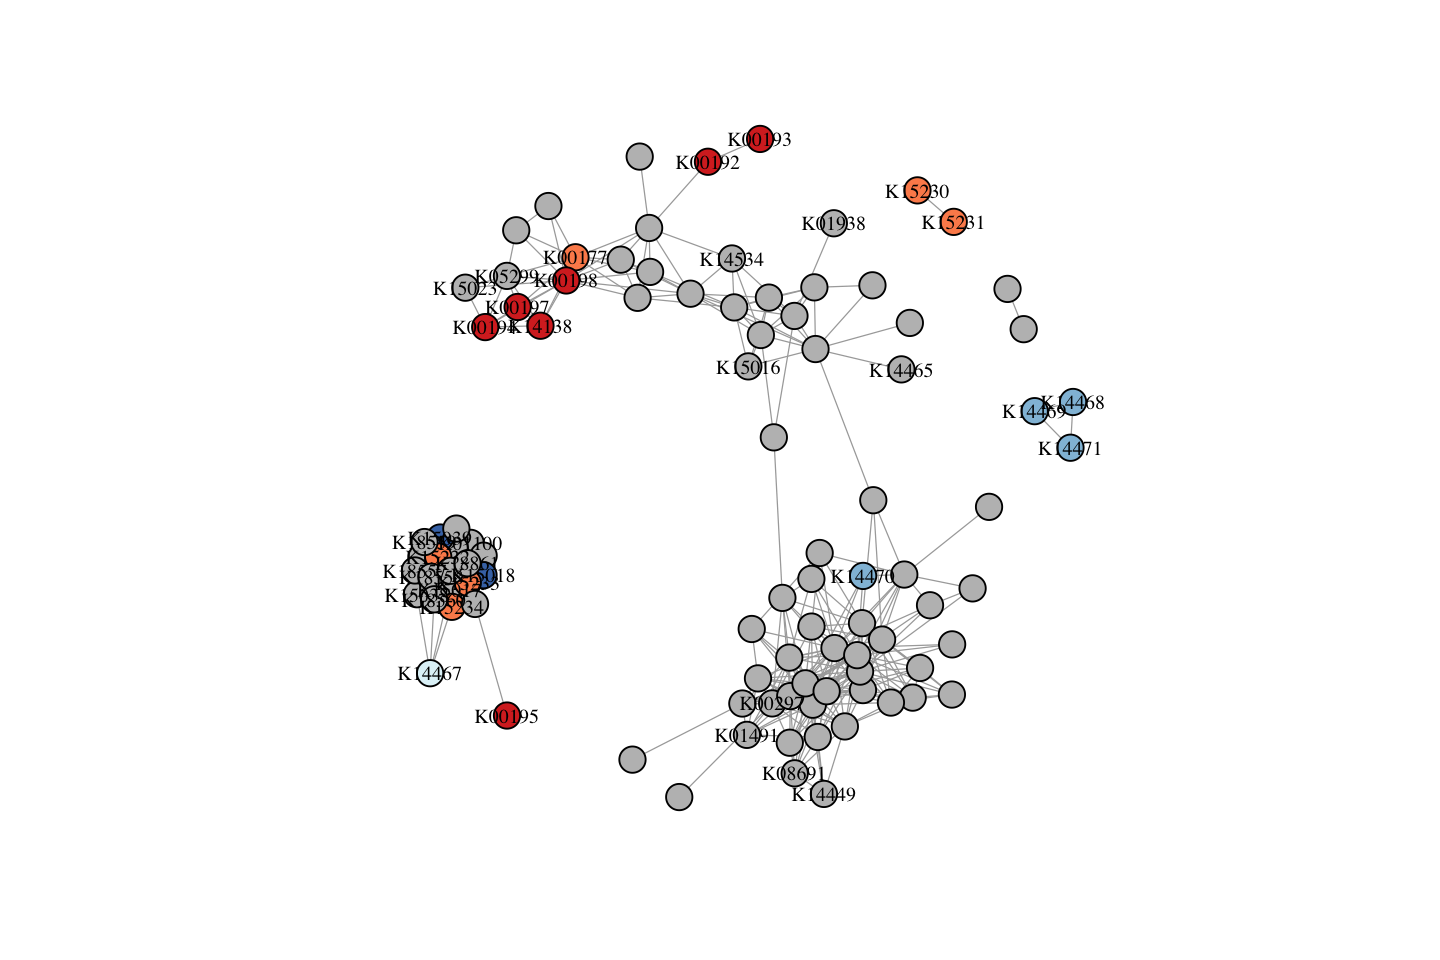

In [642]:
set.seed(1)
lay_subsurface <- igraph::layout_with_fr(g.subsurface, niter = 5000)

svglite("network_global_subsurface.svg", width = 12, height = 10)
color_graph_by_taxvar(
  graph        = g.subsurface,
  phyloseq_obj = phylo_alr_subsurface_cfp,
  tax_var      = "key_genes",
  vertex_size  = 8,
  label_cex    = 1,
  layout_fun   = lay_subsurface
)
dev.off()

color_graph_by_taxvar(
  graph        = g.subsurface,
  phyloseq_obj = phylo_alr_subsurface_cfp,
  tax_var      = "key_genes",
  vertex_size  = 8,
  label_cex    = 1,
  layout_fun   = lay_subsurface
)

In [643]:
ecount(g.subsurface)
vcount(g.subsurface)

[1] 471

[1] 96

### Only surface network

In [644]:
phylo_alr_surface_cfp

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 116 taxa and 1101 samples ]
sample_data() Sample Data:       [ 1101 samples by 433 sample variables ]
tax_table()   Taxonomy Table:    [ 116 taxa by 49 taxonomic ranks ]

In [645]:
g.surface <- build_cf_graph(phylo_alr_surface_cfp, rho_cut = rho_cut)

pdf 
  2

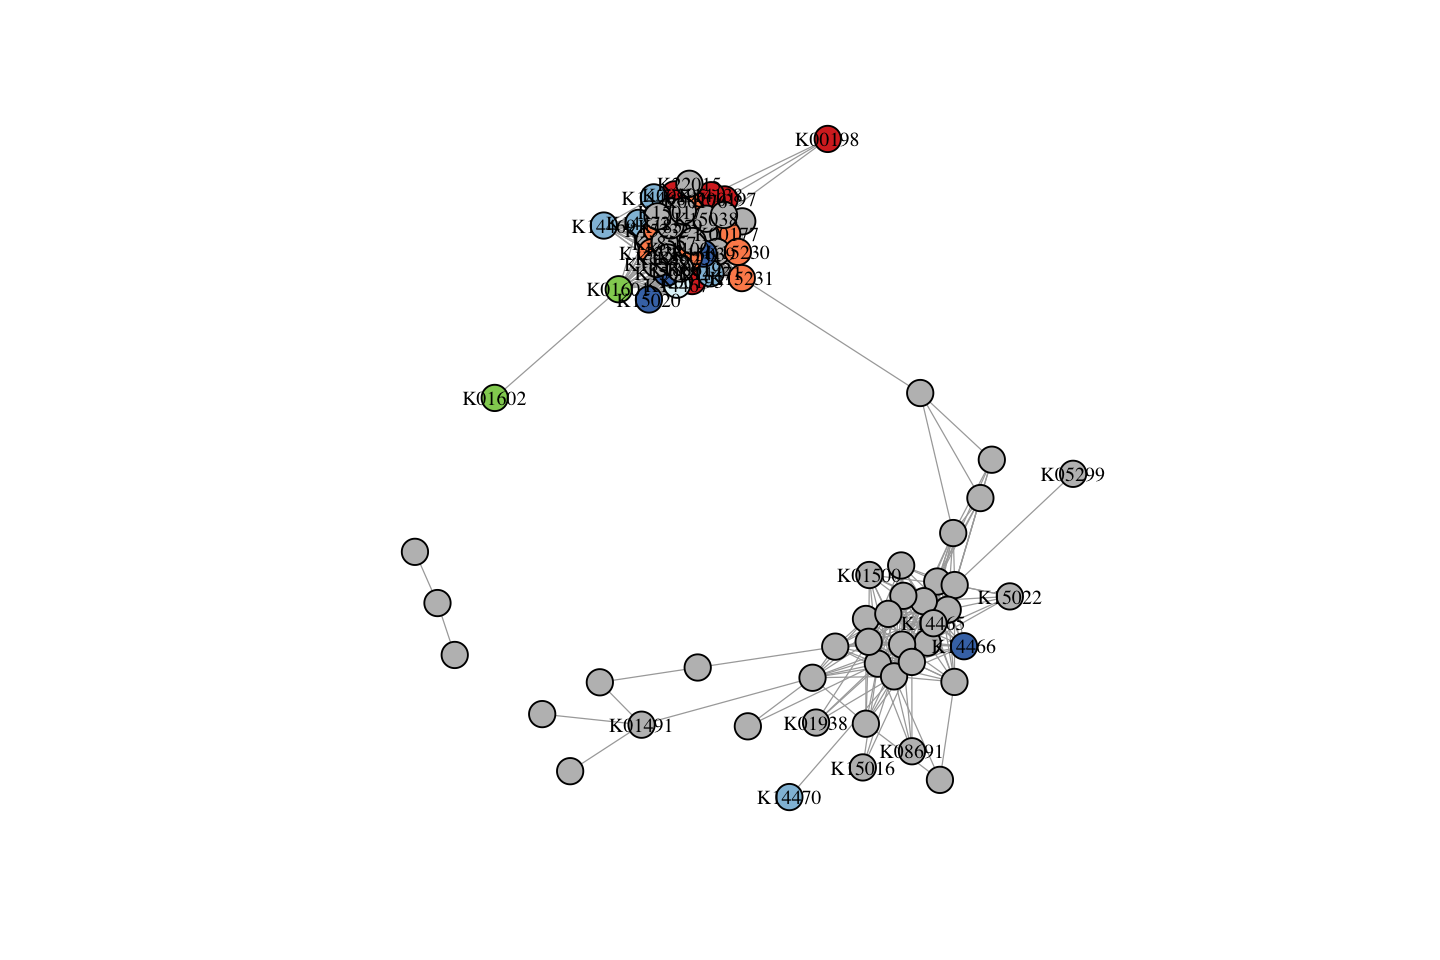

In [646]:
set.seed(1)
lay_surface <- igraph::layout_with_fr(g.surface, niter = 5000)

svglite("network_global_surface.svg", width = 12, height = 10)
color_graph_by_taxvar(
  graph        = g.surface,
  phyloseq_obj = phylo_alr_surface_cfp,
  tax_var      = "key_genes",
  vertex_size  = 8,
  label_cex    = 1,
  layout_fun   = lay_surface
)
dev.off()

color_graph_by_taxvar(
  graph        = g.surface,
  phyloseq_obj = phylo_alr_surface_cfp,
  tax_var      = "key_genes",
  vertex_size  = 8,
  label_cex    = 1,
  layout_fun   = lay_surface
)

In [647]:
ecount(g.surface)
vcount(g.surface)

[1] 940

[1] 83

In [648]:
rho_grid <- seq(0.30, 0.80, by = 0.02)

sweep_one <- function(physeq_obj, env_label, rho_grid) {
  map_dfr(rho_grid, function(rho) {
    g <- build_cf_graph(physeq_obj, rho_cut = rho)
    graph_metrics(g) %>%
      mutate(environment = env_label, rho = rho)
  })
}

surf_sweep <- sweep_one(phylo_alr_surface_cfp, "surface", rho_grid)
sub_sweep  <- sweep_one(phylo_alr_subsurface_cfp, "subsurface", rho_grid)

sweep_stats <- bind_rows(surf_sweep, sub_sweep)

In [649]:
sweep_stats

nodes,edges,density,components,giant_frac,modularity,mean_degree,transitivity,environment,rho
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
113,1612,0.25474083,1,1.0000000,0.36383307,28.530973,0.7911172,surface,0.30
108,1445,0.25008654,1,1.0000000,0.36338994,26.759259,0.8071991,surface,0.32
107,1336,0.23558455,1,1.0000000,0.36070436,24.971963,0.8218226,surface,0.34
100,1208,0.24404040,2,0.9700000,0.36360950,24.160000,0.8618174,surface,0.36
99,1145,0.23603381,2,0.9797980,0.35252840,23.131313,0.8788372,surface,0.38
92,1064,0.25418060,1,1.0000000,0.34469147,23.130435,0.9056838,surface,0.40
89,1011,0.25817160,2,0.9550562,0.32840070,22.719101,0.9146937,surface,0.42
84,967,0.27739530,2,0.9642857,0.31419079,23.023810,0.9135346,surface,0.44
81,920,0.28395062,4,0.5185185,0.30122845,22.716049,0.9124676,surface,0.46


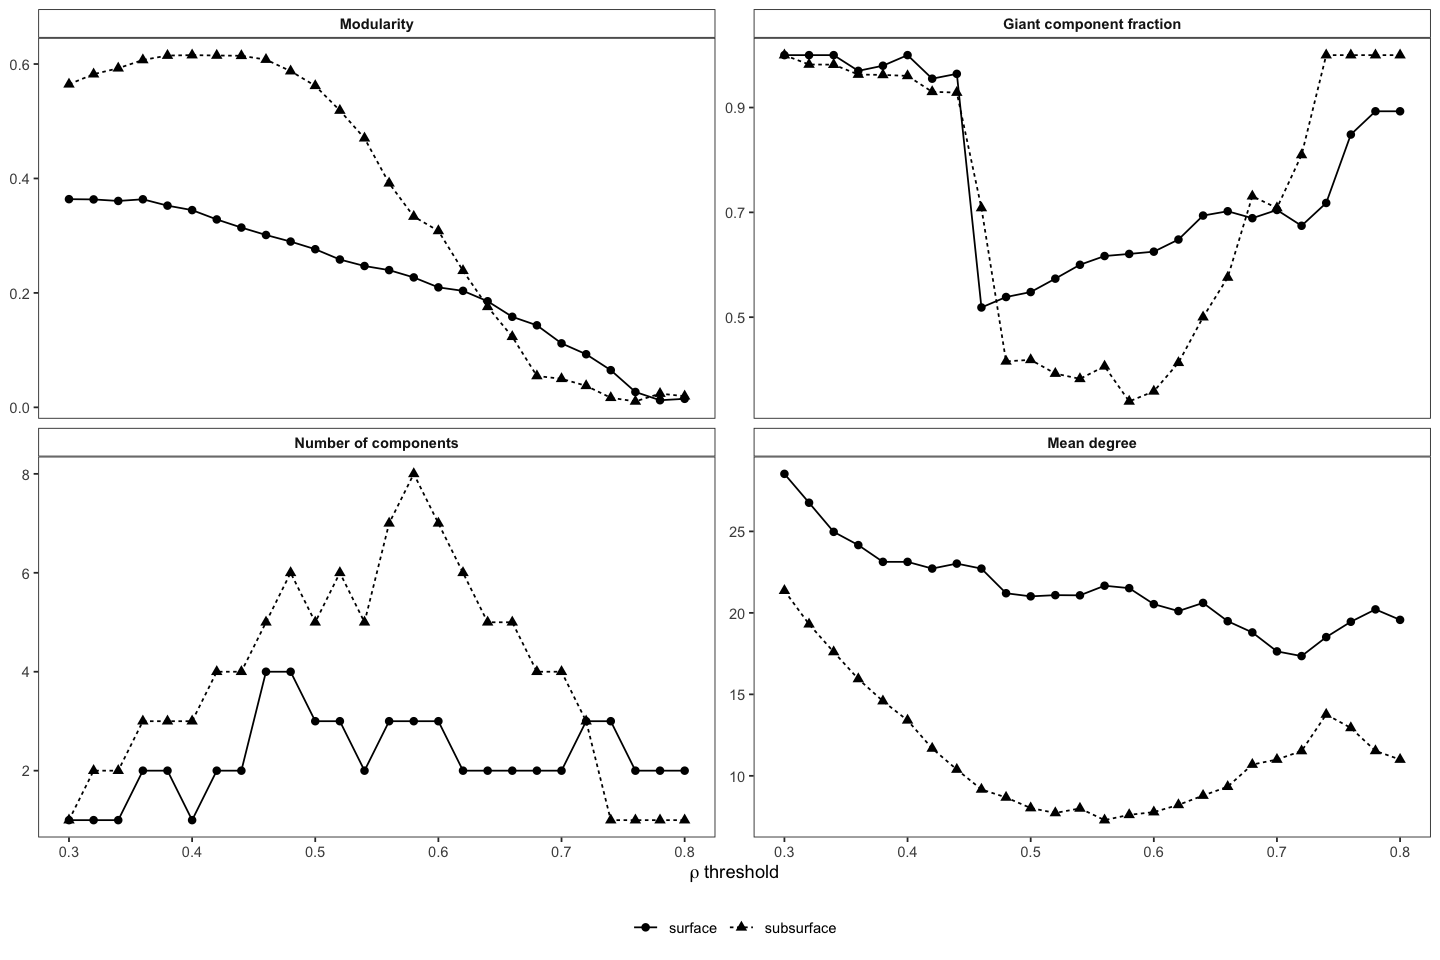

In [650]:
# make sure environment order is stable
sweep_stats$environment <- factor(
  sweep_stats$environment,
  levels = c("surface", "subsurface")
)

# long format for selected metrics
plot_df <- sweep_stats %>%
  select(rho, environment, modularity, giant_frac, components, mean_degree) %>%
  pivot_longer(
    cols = c(modularity, giant_frac, components, mean_degree),
    names_to = "metric",
    values_to = "value"
  ) %>%
  mutate(
    metric = factor(
      metric,
      levels = c("modularity", "giant_frac", "components", "mean_degree"),
      labels = c("Modularity", "Giant component fraction", "Number of components", "Mean degree")
    )
  )

p <- ggplot(plot_df, aes(x = rho, y = value, group = environment, shape = environment)) +
  geom_line(aes(linetype = environment), linewidth = 0.5, color = "black") +
  geom_point(size = 2, color = "black", fill = "white", stroke = 0.6) +
  facet_wrap(~ metric, scales = "free_y", ncol = 2) +
  theme_bw() +
  labs(
    x = expression(rho~threshold),
    y = NULL
  ) +
  theme(
    panel.grid = element_blank(),
    strip.background = element_rect(fill = "white"),
    strip.text = element_text(face = "bold"),
    legend.title = element_blank(),
    legend.position = "bottom"
  )

p

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


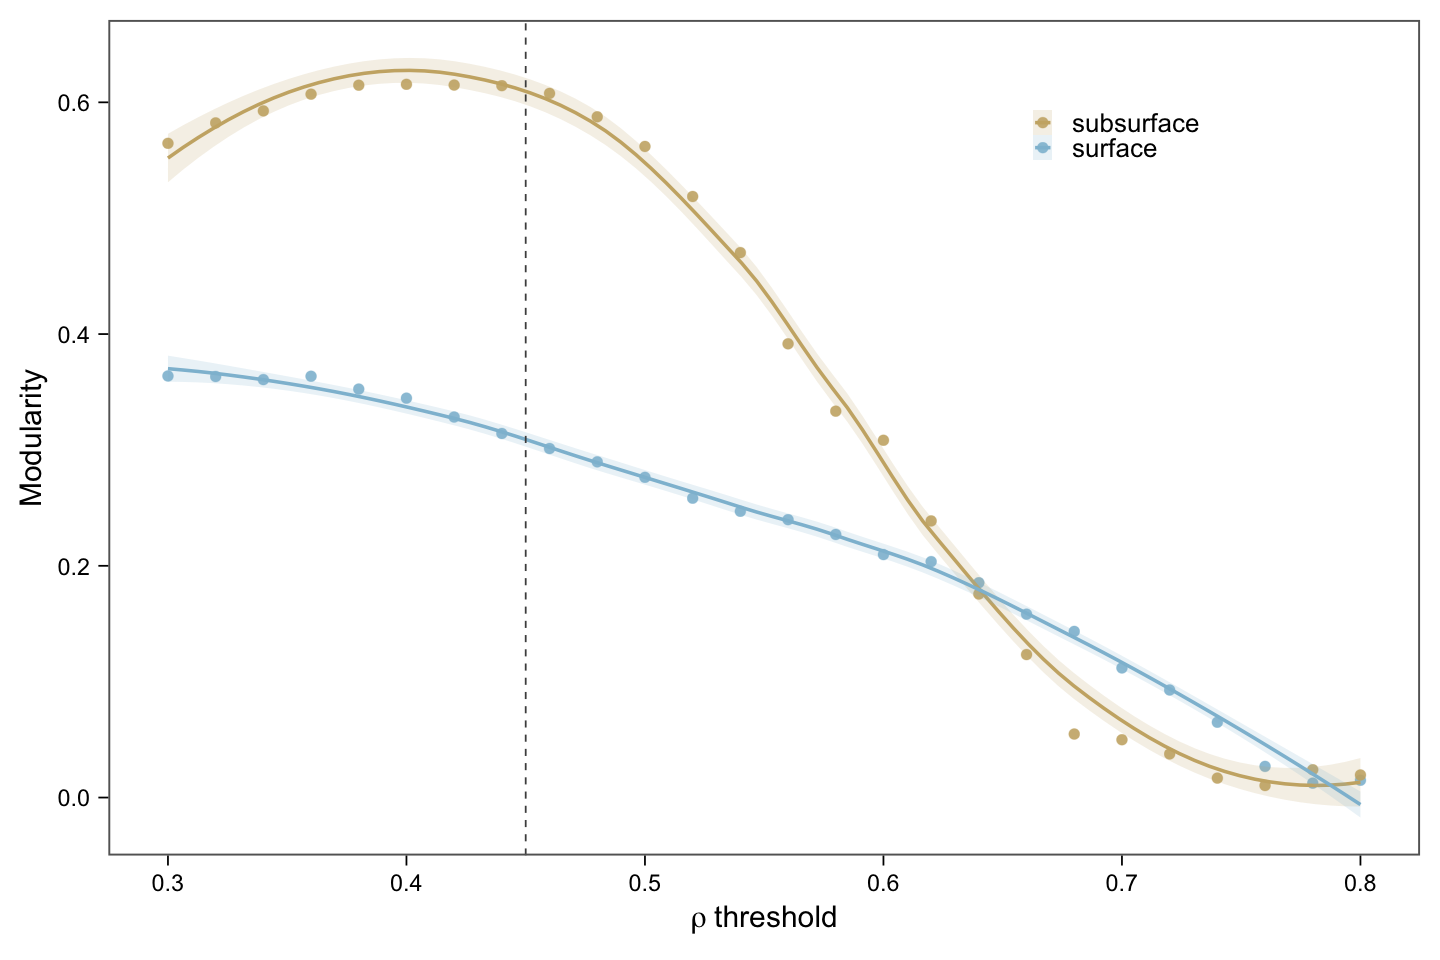

In [746]:
mod_df <- sweep_stats %>%
  select(rho, environment, modularity) %>%
  mutate(
    environment = factor(environment, levels = c("subsurface", "surface"))
  )

p_mod <- ggplot(mod_df, aes(x = rho, y = modularity, color = environment, fill = environment)) +
  geom_point(size = 3, alpha = 0.9) +
  geom_smooth(method = "loess", se = TRUE, linewidth = 1.0, alpha = 0.18, span = 0.75) +
  geom_vline(xintercept = 0.45, linetype = "dashed", linewidth = 0.5, color = "grey30") +
  labs(
    x = expression(rho ~ threshold),
    y = "Modularity",
    color = NULL,
    fill = NULL
  ) +
  scale_color_manual(values = c(
    "subsurface" = "#cab074",
    "surface" = "#8ebed6"
  )) +
  scale_fill_manual(values = c(
    "subsurface" = "#cab074",
    "surface" = "#8ebed6"
  )) +
  theme_classic() +
  theme_glab(base_size = 24) +
  theme(
    panel.background = element_blank(),
    plot.background = element_blank(),
    legend.background = element_blank(),
    legend.key = element_blank(),

    axis.title.x = element_text(size = 18, color = "black"),
    axis.title.y = element_text(size = 18, color = "black"),
    axis.text.x = element_text(size = 14, color = "black"),
    axis.text.y = element_text(size = 14, color = "black"),

    axis.line = element_blank(),
    axis.ticks = element_line(color = "black", linewidth = 0.5),

    legend.text = element_text(color = "black"),
    legend.position = c(0.7, 0.9),
    legend.justification = c(0, 1),
    legend.title = element_blank(),
    legend.margin = margin(4, 4, 4, 4)
  )

p_mod

ggsave("modularity_percolation.svg", width = 7, height = 4.5, bg = "transparent")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


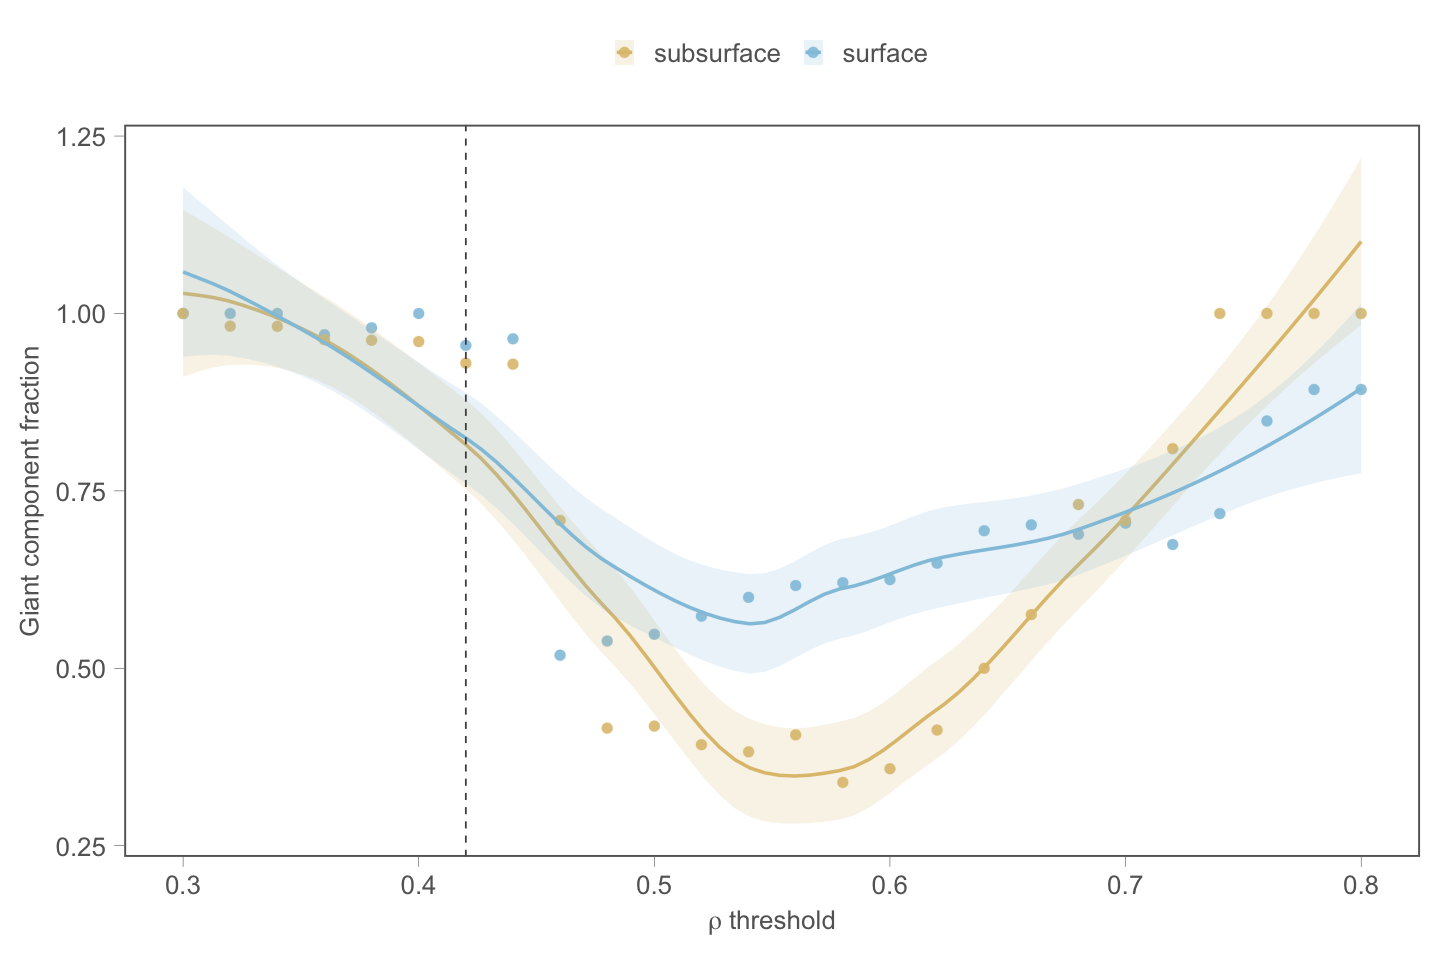

In [652]:
mod_df <- sweep_stats %>%
  select(rho, environment, giant_frac) %>%
  mutate(
    environment = factor(environment, levels = c("subsurface", "surface"))
  )

p_mod <- ggplot(mod_df, aes(x = rho, y = giant_frac, color = environment, fill = environment)) +
  geom_point(size = 3, alpha = 0.9) +
  geom_smooth(method = "loess", se = TRUE, linewidth = 1.0, alpha = 0.18, span = 0.75) +
  theme_classic() +
  labs(
    x = expression(rho~threshold),
    y = "Giant component fraction",
    color = NULL,
    fill = NULL
  ) +

 geom_vline(xintercept = 0.42, linetype = "dashed", linewidth = 0.5, color = "grey30") +

  scale_color_manual(values = c(
    "subsurface" = "#dfc27d",
    "surface"    = "#92c5de"
  )) +
  scale_fill_manual(values = c(
    "subsurface" = "#dfc27d",
    "surface"    = "#92c5de"
  )) +

theme_glab(base_size = 24)+

  theme(
    legend.position = "top",
    legend.title = element_blank()
  )

p_mod

ggsave("giant-components_percolation.svg", width = 12, height = 8)

In [653]:
get_clusters <- function(g, min_size = 3) {
  cl <- cluster_louvain(g, weights = E(g)$weight)
  memb <- membership(cl)

  out <- tibble(
    gene = names(memb),
    cluster = as.integer(memb)
  ) %>%
    add_count(cluster, name = "cluster_size") %>%
    filter(cluster_size >= min_size)

  list(
    membership_table = out,
    clustering = cl
  )
}

surf_clusters <- get_clusters(g.surface, min_size = 3)
sub_clusters  <- get_clusters(g.subsurface, min_size = 3)

In [654]:
color_graph_by_cluster <- function(g, cluster_tbl, seed = 1, niter = 5000,
                                   vertex_size = 6, label_cex = 0.9) {
  
  cluster_tbl <- cluster_tbl %>%
    distinct(gene, cluster)

  keep_genes <- intersect(V(g)$name, cluster_tbl$gene)
  g2 <- induced_subgraph(g, vids = V(g)[name %in% keep_genes])

  cl_vec <- cluster_tbl$cluster[match(V(g2)$name, cluster_tbl$gene)]
  V(g2)$cluster <- cl_vec

  cl_ids <- sort(unique(V(g2)$cluster))
  pal <- viridis(length(cl_ids))
  V(g2)$color <- pal[match(V(g2)$cluster, cl_ids)]

  set.seed(seed)
  lay <- layout_with_fr(g2, niter = niter)

  plot(
    g2,
    layout = lay,
    vertex.color = V(g2)$color,
    vertex.size = vertex_size,
    vertex.label = V(g2)$name,
    vertex.label.cex = label_cex,
    edge.color = "grey80"
  )

  invisible(g2)
}

In [655]:
subsurface_lists <- sub_clusters$membership_table %>%
  arrange(cluster, gene) %>%
  group_by(cluster) %>%
  summarise(KOs = list(gene), .groups = "drop")

In [656]:
surface_lists <- surf_clusters$membership_table %>%
  arrange(cluster, gene) %>%
  group_by(cluster) %>%
  summarise(KOs = list(gene), .groups = "drop")

In [657]:
for (i in seq_len(nrow(subsurface_lists))) {
  cat("\n### Subsurface cluster", subsurface_lists$cluster[i], "###\n")
  cat(paste(subsurface_lists$KOs[[i]], collapse = "\n"))
  cat("\n")
}


### Subsurface cluster 1 ###
K00024
K00031
K00134
K00239
K00240
K00241
K00242
K00281
K00297
K00382
K00605
K00615
K00626
K00927
K01491
K01595
K01623
K01676
K01679
K01681
K01783
K01803
K01807
K01847
K01902
K01903
K01958
K01961
K01962
K01963
K02160
K02446
K03841
K05606
K08691
K11532
K14449
K14470

### Subsurface cluster 2 ###
K00150
K00169
K00170
K00171
K00172
K00174
K00175
K00177
K00192
K00193
K00194
K00197
K00198
K00282
K00283
K01006
K01677
K01678
K01808
K01848
K01849
K01938
K01960
K03737
K05299
K14138
K14465
K14534
K15016
K15023

### Subsurface cluster 3 ###
K00195
K01100
K01964
K14467
K15017
K15018
K15036
K15037
K15038
K15039
K15232
K15233
K15234
K18557
K18558
K18559
K18560
K18860
K18861
K25008
K25124

### Subsurface cluster 5 ###
K14468
K14469
K14471


In [658]:
for (i in seq_len(nrow(surface_lists))) {
  cat("\n### Surface cluster", surface_lists$cluster[i], "###\n")
  cat(paste(surface_lists$KOs[[i]], collapse = "\n"))
  cat("\n")
}


### Surface cluster 1 ###
K00024
K00031
K00134
K00169
K00170
K00172
K00174
K00175
K00239
K00240
K00282
K00283
K00382
K00615
K00626
K01006
K01491
K01500
K01623
K01678
K01679
K01681
K01803
K01808
K01848
K01849
K01938
K01958
K01961
K02446
K03737
K05299
K08691
K14465
K14466
K14470
K15016
K15022

### Surface cluster 2 ###
K00171
K00176
K00177
K00192
K00193
K00195
K00197
K00198
K01100
K01601
K01602
K01964
K10671
K10672
K14138
K14467
K14468
K14469
K14471
K14472
K15017
K15018
K15020
K15036
K15037
K15038
K15039
K15230
K15231
K15232
K15233
K15234
K18557
K18558
K18559
K18560
K18860
K18861
K22015
K25008
K25123
K25124

### Surface cluster 3 ###
K00281
K01624
K01682


In [659]:
plot_network_clusters <- function(g, cluster_tbl,
                                  seed = 1,
                                  niter = 5000,
                                  vertex_size = 6,
                                  label_cex = 0.9,
                                  main = NULL,
                                  legend_cex = 0.8) {
  
  cluster_tbl <- cluster_tbl %>%
    distinct(gene, cluster)
  
  # attach cluster membership
  cl_vec <- cluster_tbl$cluster[match(V(g)$name, cluster_tbl$gene)]
  V(g)$cluster_plot <- cl_vec
  
  # unique clusters (sorted for stable mapping)
  cl_ids <- sort(unique(na.omit(V(g)$cluster_plot)))
  
  # viridis palette
  pal <- viridis(length(cl_ids))
  
  # assign colors (grey for non-clustered nodes)
  vcols <- rep("grey85", vcount(g))
  
  if (length(cl_ids) > 0) {
    idx <- which(!is.na(V(g)$cluster_plot))
    vcols[idx] <- pal[match(V(g)$cluster_plot[idx], cl_ids)]
  }
  
  # layout
  set.seed(seed)
  lay <- layout_with_fr(g, niter = niter)
  
  # plot
  plot(
    g,
    layout = lay,
    vertex.color = vcols,
    vertex.size = vertex_size,
    vertex.label = V(g)$name,
    vertex.label.cex = label_cex,
    vertex.frame.width = 1.5,
    edge.color = "grey80",
    main = main
  )
  
  # legend (only if clusters exist)
  if (length(cl_ids) > 0) {
    legend(
      "topleft",
      legend = paste("Cluster", cl_ids),
      col = pal,
      pch = 16,
      pt.cex = 1.2,
      bty = "n",
      cex = legend_cex
    )
  }
  
  invisible(list(graph = g, layout = lay))
}

pdf 
  2

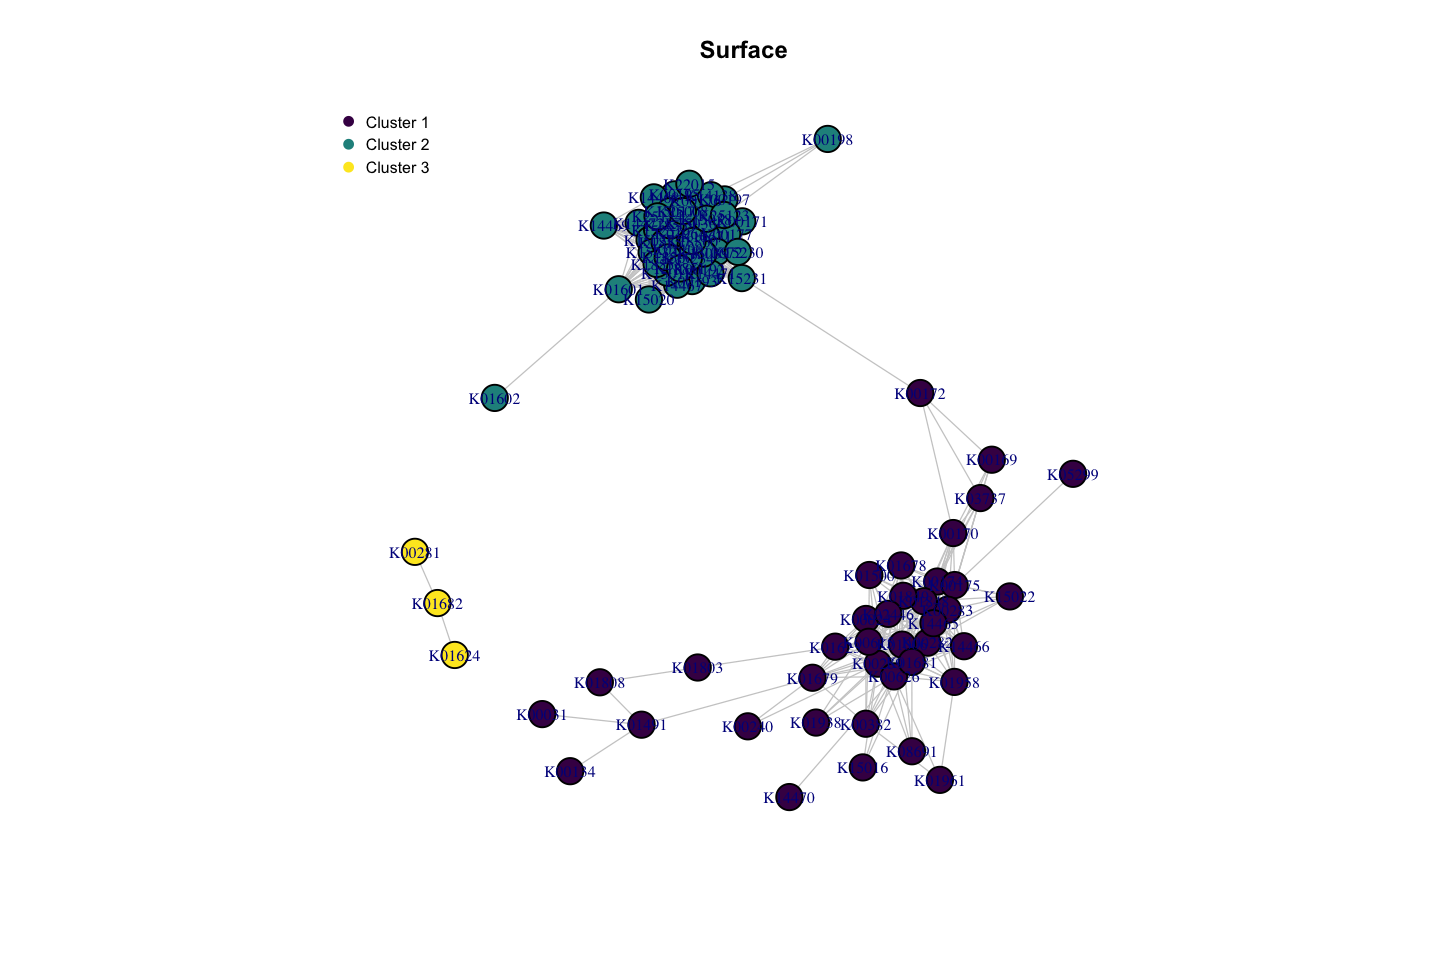

In [660]:
#svg("Supplementary_network_clusters_surface.svg", width = 12, height = 10)

plot_network_clusters(
  g.surface,
  surf_clusters$membership_table,
  seed = 1,
  niter = 5000,
  vertex_size = 8,
  label_cex = 0.8,
  main = "Surface"
)

#dev.off()

svg("Supplementary_network_clusters_subsurface.svg", width = 12, height = 10)
plot_network_clusters(
  g.subsurface,
  sub_clusters$membership_table,
  seed = 1,
  niter = 5000,
  vertex_size = 8,
  label_cex = 0.8,
  main = "Subsurface"
)

dev.off()

In [661]:
memb <- sub_clusters$membership_table %>%
  filter(cluster %in% c(1,2))

ed <- igraph::as_data_frame(g.subsurface, what = "edges")

ed <- ed %>%
  left_join(memb, by = c("from" = "gene")) %>%
  rename(cluster_from = cluster) %>%
  left_join(memb, by = c("to" = "gene")) %>%
  rename(cluster_to = cluster)

ed12 <- ed %>%
  filter(cluster_from %in% c(1,2) & cluster_to %in% c(1,2))

ed12 <- ed12 %>%
  mutate(type = case_when(
    cluster_from == 1 & cluster_to == 1 ~ "within_1",
    cluster_from == 2 & cluster_to == 2 ~ "within_2",
    TRUE ~ "between"
  ))

ed12 %>% count(type)

type,n
<chr>,<int>
between,2
within_1,206
within_2,82


In [662]:
ed12 %>%
  group_by(type) %>%
  summarise(
    n = n(),
    mean_weight = mean(weight),
    median_weight = median(weight)
  )

type,n,mean_weight,median_weight
<chr>,<int>,<dbl>,<dbl>
between,2,0.4658011,0.4658011
within_1,206,0.5258703,0.5161265
within_2,82,0.5292970,0.5038279


In [663]:
n_between <- sum(ed12$type == "between")
n_total <- nrow(ed12)

n_between / n_total

[1] 0.006896552

In [664]:
ed <- igraph::as_data_frame(g.surface, what = "edges")

memb <- surf_clusters$membership_table %>%
  filter(cluster %in% c(1, 3))

ed <- ed %>%
  left_join(memb, by = c("from" = "gene")) %>%
  rename(cluster_from = cluster) %>%
  left_join(memb, by = c("to" = "gene")) %>%
  rename(cluster_to = cluster)

ed13 <- ed %>%
  filter(cluster_from %in% c(1,3) & cluster_to %in% c(1,3))

ed13 <- ed13 %>%
  mutate(type = case_when(
    cluster_from == 1 & cluster_to == 1 ~ "within_1",
    cluster_from == 3 & cluster_to == 3 ~ "within_3",
    TRUE ~ "between"
  ))

ed13 %>%
  group_by(type) %>%
  summarise(
    n = n(),
    mean_weight = mean(weight),
    median_weight = median(weight)
  )

n_between <- sum(ed13$type == "between")
n_total <- nrow(ed13)

n_between / n_total

type,n,mean_weight,median_weight
<chr>,<int>,<dbl>,<dbl>
within_1,211,0.5758078,0.5606739
within_3,2,0.4777622,0.4777622


[1] 0

In [665]:
rho_star <- 0.42

bootstrap_cluster_stability <- function(physeq_obj, rho_cut = 0.42,
                                        n_boot = 200, prop_samples = 0.8,
                                        min_size = 3, seed = 1) {
  set.seed(seed)

  M <- as(otu_table(physeq_obj), "matrix")
  if (!taxa_are_rows(otu_table(physeq_obj))) {
    M <- t(M)
  }

  sd_taxa <- apply(M, 1, sd, na.rm = TRUE)
  M <- M[sd_taxa > 0 & is.finite(sd_taxa), , drop = FALSE]

  genes <- rownames(M)
  coassign <- matrix(0, nrow = length(genes), ncol = length(genes),
                     dimnames = list(genes, genes))
  present  <- matrix(0, nrow = length(genes), ncol = length(genes),
                     dimnames = list(genes, genes))

  n_samp <- ncol(M)
  boot_n <- ceiling(prop_samples * n_samp)

  for (b in seq_len(n_boot)) {
    idx <- sort(sample(seq_len(n_samp), size = boot_n, replace = FALSE))
    Mb <- M[, idx, drop = FALSE]

    sdb <- apply(Mb, 1, sd, na.rm = TRUE)
    Mb <- Mb[sdb > 0 & is.finite(sdb), , drop = FALSE]

    corr <- cor(t(Mb), use = "pairwise.complete.obs", method = "spearman")
    corr[is.na(corr)] <- 0
    diag(corr) <- 0
    corr[corr < rho_cut] <- 0

    g <- graph_from_adjacency_matrix(corr, mode = "undirected", weighted = TRUE, diag = FALSE)
    g <- igraph::simplify(g, remove.multiple = TRUE, remove.loops = TRUE)
    g <- delete_vertices(g, which(degree(g) == 0))

    if (vcount(g) < 2) next

    cl <- cluster_louvain(g, weights = E(g)$weight)
    memb <- membership(cl)

    tb <- tibble(gene = names(memb), cluster = as.integer(memb)) %>%
      add_count(cluster, name = "cluster_size") %>%
      filter(cluster_size >= min_size)

    gkeep <- tb$gene
    if (length(gkeep) < 2) next

    present[gkeep, gkeep] <- present[gkeep, gkeep] + 1

    split_genes <- split(tb$gene, tb$cluster)
    for (grp in split_genes) {
      coassign[grp, grp] <- coassign[grp, grp] + 1
    }
  }

  stability <- coassign / pmax(present, 1)
  diag(stability) <- 1

  return(stability)
}

surf_stab <- bootstrap_cluster_stability(phylo_alr_surface_cfp, rho_cut = rho_star)
sub_stab  <- bootstrap_cluster_stability(phylo_alr_subsurface_cfp, rho_cut = rho_star)

In [666]:
get_cluster_stability_summary <- function(stab_mat, cluster_tbl, clusters = c(1,2)) {
  
  genes <- cluster_tbl %>%
    filter(cluster %in% clusters)
  
  g1 <- genes %>% filter(cluster == clusters[1]) %>% pull(gene)
  g2 <- genes %>% filter(cluster == clusters[2]) %>% pull(gene)
  
  # within
  within_1 <- stab_mat[g1, g1]
  within_2 <- stab_mat[g2, g2]
  
  # between
  between <- stab_mat[g1, g2]
  
  tibble(
    group = c("within_1", "within_2", "between"),
    mean = c(mean(within_1), mean(within_2), mean(between)),
    median = c(median(within_1), median(within_2), median(between))
  )
}

get_cluster_stability_summary(sub_stab, sub_clusters$membership_table, c(1,2))

group,mean,median
<chr>,<dbl>,<dbl>
within_1,0.996948412,1
within_2,0.997419524,1
between,0.001758324,0


In [667]:
get_cluster_stability_summary(surf_stab, surf_clusters$membership_table, c(1,2))

group,mean,median
<chr>,<dbl>,<dbl>
within_1,0.8804224,1
within_2,1.0000000,1
between,0.0000000,0


In [668]:
save.image()

In [669]:
get_gene_matrix <- function(physeq_obj) {
  M <- as(otu_table(physeq_obj), "matrix")
  if (!taxa_are_rows(otu_table(physeq_obj))) {
    M <- t(M)
  }
  sd_taxa <- apply(M, 1, sd, na.rm = TRUE)
  M <- M[sd_taxa > 0 & is.finite(sd_taxa), , drop = FALSE]
  M
}

compute_cluster_scores <- function(physeq_obj, membership_table) {
  M <- get_gene_matrix(physeq_obj)

  # keep only genes present in matrix
  membership_table <- membership_table %>%
    filter(gene %in% rownames(M))

  # z-score each gene across samples
  Mz <- t(scale(t(M)))
  Mz[is.na(Mz)] <- 0

  score_list <- lapply(split(membership_table$gene, membership_table$cluster), function(gs) {
    X <- t(Mz[gs, , drop = FALSE])  # samples x genes
    if (ncol(X) == 1) {
      sc <- as.numeric(X[, 1])
    } else {
      pc <- prcomp(X, center = FALSE, scale. = FALSE)
      sc <- pc$x[, 1]
    }
    sc
  })

  score_df <- as.data.frame(score_list)
  colnames(score_df) <- paste0("cluster_", names(score_list))
  score_df$SampleID <- colnames(M)

  as_tibble(score_df)
}

surf_scores <- compute_cluster_scores(phylo_rpo_surface_cfp, surf_clusters$membership_table)
sub_scores  <- compute_cluster_scores(phylo_rpo_subsurface_cfp, sub_clusters$membership_table)

In [670]:
correlate_clusters_env <- function(score_df, env_df, sample_col = "SampleID", min_n = 20) {
  dat <- left_join(score_df, env_df, by = sample_col)

  cluster_cols <- grep("^cluster_", names(dat), value = TRUE)
  env_cols <- setdiff(names(env_df), sample_col)

  res <- purrr::map_dfr(cluster_cols, function(cl) {
    purrr::map_dfr(env_cols, function(ev) {
      x <- dat[[cl]]
      y <- dat[[ev]]

      ok <- is.finite(x) & is.finite(y)
      n_ok <- sum(ok)

      if (n_ok < min_n) {
        return(tibble(cluster = cl, variable = ev, n = n_ok,
                      rho = NA_real_, p = NA_real_))
      }

      ct <- suppressWarnings(cor.test(x[ok], y[ok], method = "spearman", exact = FALSE))
      tibble(cluster = cl, variable = ev, n = n_ok,
             rho = unname(ct$estimate), p = ct$p.value)
    })
  })

  res %>%
    group_by(cluster) %>%
    mutate(p_adj = p.adjust(p, method = "BH")) %>%
    ungroup()
}

In [671]:
colnames(sample_data(phylo_rpo_surface_cfp)[,c(26:36,40:60,151:158,167:180)])

[1] "temp"       "ph"         "spc"        "orp"        "do_sat"    
 [6] "do"         "tds"        "sal"        "alk_tot"    "sio2"      
[11] "sulfide"    "cl"         "br"         "no3"        "so4"       
[16] "po4"        "li"         "na"         "nh4"        "k"         
[21] "mg"         "ca"         "v"          "mn"         "fe"        
[26] "co"         "ni"         "cu"         "zn"         "se"        
[31] "mo"         "w"          "ch4_dry"    "s_dry"      "he_dry"    
[36] "h2_dry"     "o2_dry"     "ar_dry"     "n2_dry"     "co_dry"    
[41] "ar_dis"     "n2_dis"     "d13CO2_dis" "d13CH4_dis" "co2_he"    
[46] "co2_ar"     "co2_ch4"    "he4"        "r_ra"       "rc_ra"     
[51] "X"          "he4_ne20"   "co2_3he"    "co2_4he"

In [672]:
env_surface <- data.frame(sample_data(phylo_rpo_surface_cfp)[,c(26:36,40:60,151:158,167:180)]) %>%
  rownames_to_column("SampleID")

env_subsurface <- data.frame(sample_data(phylo_rpo_subsurface_cfp)[,c(26:36,40:60,151:158,167:180)]) %>%
  rownames_to_column("SampleID")

Warning message in cor(as.matrix(env_subsurface[, -1]), use = "pairwise.complete.obs", :
“l'écart type est nul”
Warning message in cor(as.matrix(env_subsurface[, -1]), use = "pairwise.complete.obs", :
“l'écart type est nul”
La méthode "ward" a été renommée "ward.D"; notez la nouvelle méthode "ward.D2"

La méthode "ward" a été renommée "ward.D"; notez la nouvelle méthode "ward.D2"



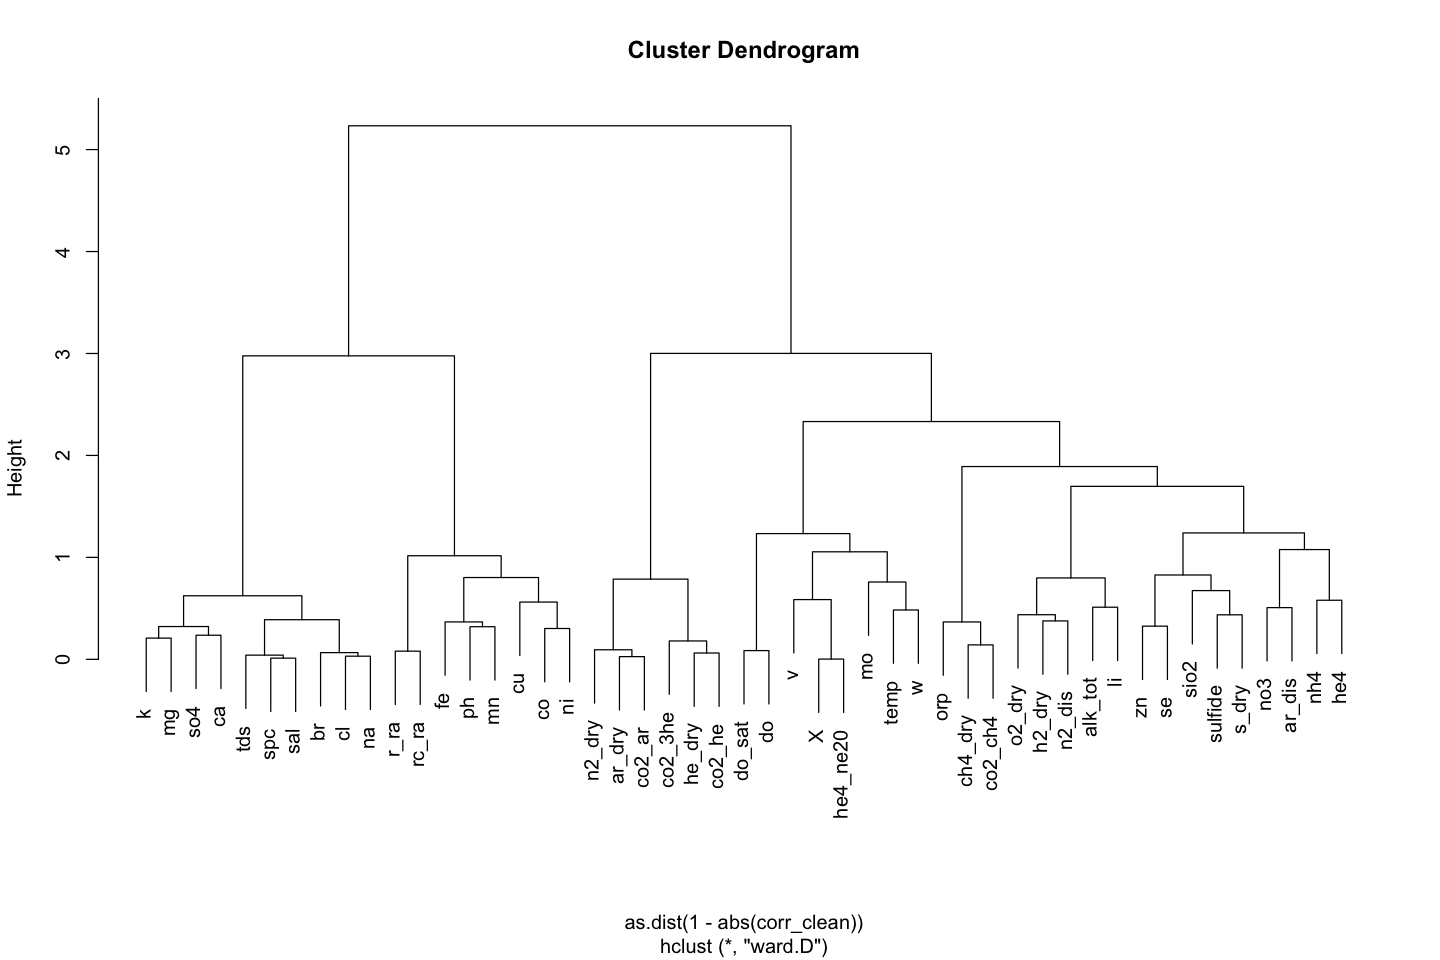

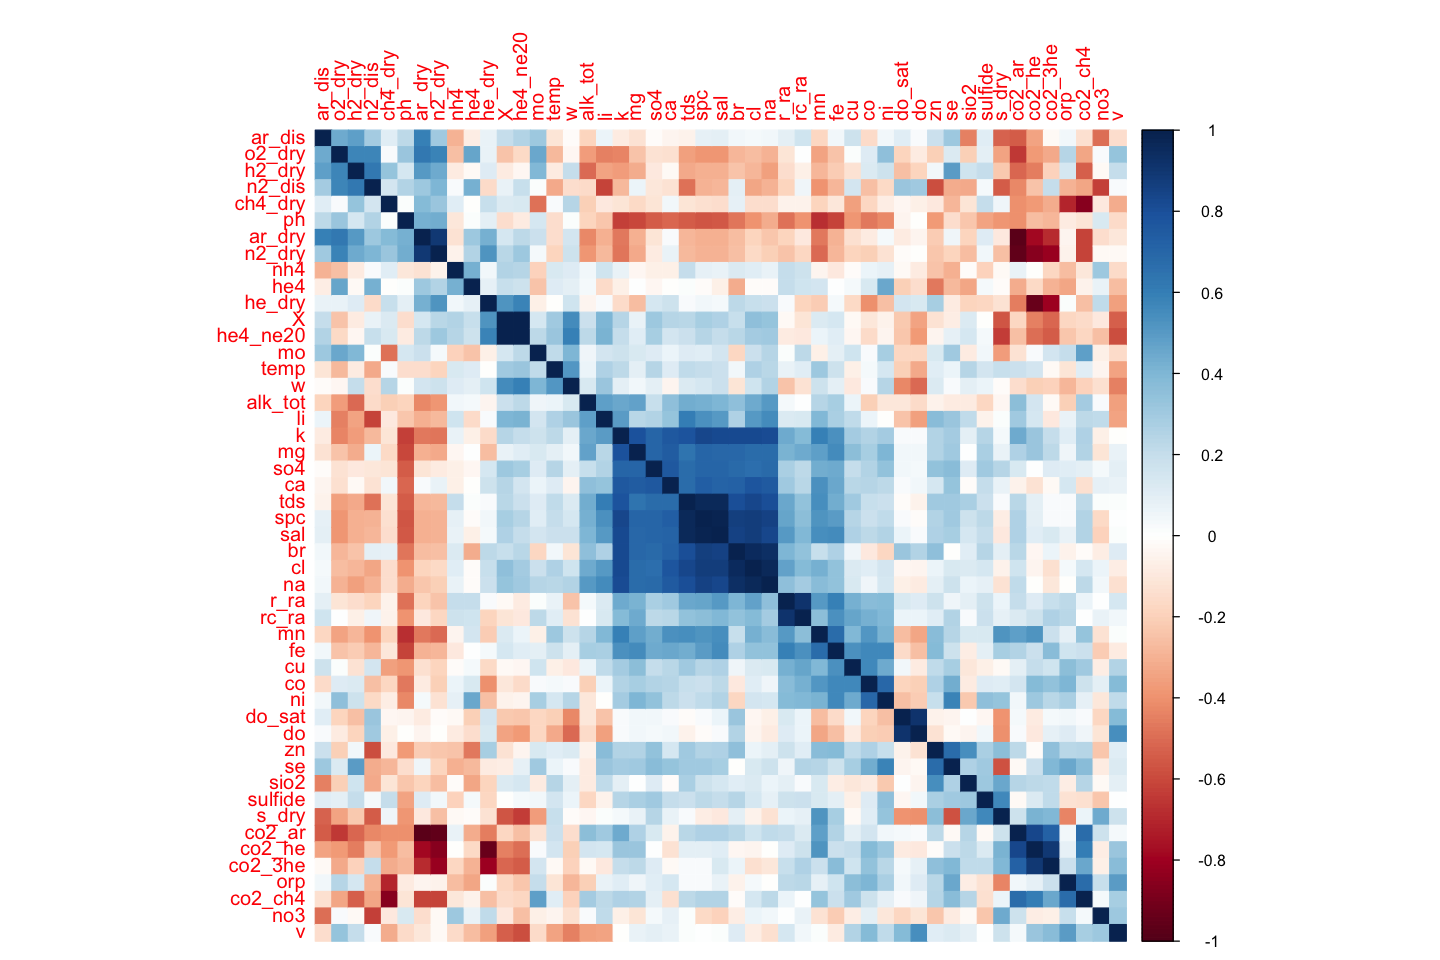

In [673]:
cor_mat <- cor(as.matrix(env_subsurface[,-1]),
            use = "pairwise.complete.obs",
            method = "spearman")

# remove variables with any NA correlation
keep <- apply(cor_mat, 1, function(x) all(is.finite(x)))

corr_clean <- cor_mat[keep, keep]

hc_corr <- hclust(as.dist(1 - abs(corr_clean)), method = "ward")

plot(hc_corr)
              
# visualize
library(corrplot)

#svg("Supplementary_env_correlation.svg", width = 12, height = 12)
corrplot(corr_clean, method = "color", order="hclust", hclust.method = "ward")
#dev.off()

In [674]:
res_surface <- correlate_clusters_env(
  surf_scores,
  env_surface,
  sample_col = "SampleID",
  min_n = 20
)

res_subsurface <- correlate_clusters_env(
  sub_scores,
  env_subsurface,
  sample_col = "SampleID",
  min_n = 20
)

In [675]:
res_surface %>% arrange(p_adj) %>% head(10)
res_subsurface %>% arrange(p_adj) %>% head(80)

cluster,variable,n,rho,p,p_adj
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
cluster_3,ph,587,0.6788930,1.584225e-80,3.168449e-79
cluster_1,ph,587,0.4531215,4.629541e-31,9.259081e-30
cluster_2,ph,587,-0.3957086,1.922865e-23,3.845730e-22
cluster_3,tds,301,0.4301648,5.478994e-15,5.478994e-14
cluster_1,tds,301,-0.3411674,1.219025e-09,1.219025e-08
cluster_2,temp,701,-0.2047894,4.487886e-08,4.487886e-07
cluster_3,po4,243,-0.3277009,1.722276e-07,1.148184e-06
cluster_3,sal,162,0.3458957,6.531898e-06,3.265949e-05
cluster_2,ca,154,-0.3070707,1.072346e-04,7.148971e-04


cluster,variable,n,rho,p,p_adj
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
cluster_3,temp,392,-0.4138580,1.185115e-17,6.399621e-16
cluster_2,temp,392,-0.3587382,2.385212e-13,1.288014e-11
cluster_2,do,283,0.3370845,6.003587e-09,1.620968e-07
cluster_1,spc,335,0.3116220,5.607720e-09,3.028169e-07
cluster_1,sal,323,0.3025944,2.892863e-08,7.810729e-07
cluster_1,ph,389,-0.2673676,8.597139e-08,1.160614e-06
cluster_1,tds,330,0.2917367,6.760852e-08,1.160614e-06
cluster_2,v,185,0.3743763,1.523211e-07,2.741780e-06
cluster_1,orp,203,-0.3327155,1.234071e-06,1.332796e-05


In [676]:
res_surface_filt <- res_surface %>%
  filter(abs(rho) >= 0.25, p_adj < 0.01)

res_subsurface_filt <- res_subsurface %>%
  filter(abs(rho) >= 0.25, p_adj < 0.01)

In [677]:
res_surface_filt %>% arrange(p_adj) %>% head(10)

cluster,variable,n,rho,p,p_adj
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
cluster_3,ph,587,0.6788930,1.584225e-80,3.168449e-79
cluster_1,ph,587,0.4531215,4.629541e-31,9.259081e-30
cluster_2,ph,587,-0.3957086,1.922865e-23,3.845730e-22
cluster_3,tds,301,0.4301648,5.478994e-15,5.478994e-14
cluster_1,tds,301,-0.3411674,1.219025e-09,1.219025e-08
cluster_3,po4,243,-0.3277009,1.722276e-07,1.148184e-06
cluster_3,sal,162,0.3458957,6.531898e-06,3.265949e-05
cluster_2,ca,154,-0.3070707,1.072346e-04,7.148971e-04
cluster_2,so4,157,-0.2691769,6.520953e-04,3.260476e-03


In [678]:
res_subsurface_filt %>% arrange(p_adj) %>% arrange(cluster)

cluster,variable,n,rho,p,p_adj
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
cluster_1,spc,335,0.3116220,5.607720e-09,3.028169e-07
cluster_1,sal,323,0.3025944,2.892863e-08,7.810729e-07
cluster_1,ph,389,-0.2673676,8.597139e-08,1.160614e-06
cluster_1,tds,330,0.2917367,6.760852e-08,1.160614e-06
cluster_1,orp,203,-0.3327155,1.234071e-06,1.332796e-05
cluster_1,fe,174,0.3551657,1.517564e-06,1.365808e-05
cluster_1,k,324,0.2519267,4.402381e-06,3.396123e-05
cluster_1,mn,197,0.3155859,6.264863e-06,4.228783e-05
cluster_1,ni,141,0.3434276,3.056681e-05,1.650608e-04


In [679]:
res_subsurface_filt %>% count(cluster)
res_surface_filt %>% count(cluster)

cluster,n
<chr>,<int>
cluster_1,10
cluster_2,9
cluster_3,1
cluster_5,3


cluster,n
<chr>,<int>
cluster_1,2
cluster_2,3
cluster_3,5


In [680]:
# Are variables partitioned?
res_subsurface_filt %>% count(variable, sort = TRUE)

variable,n
<chr>,<int>
X,2
temp,2
v,2
w,2
ch4_dry,1
co2_ch4,1
do,1
do_sat,1
fe,1


In [681]:
res_surface_filt %>% count(variable, sort = TRUE)

variable,n
<chr>,<int>
ph,3
tds,2
ca,1
fe,1
po4,1
sal,1
so4,1


In [682]:
res_surface_filt %>%
  group_by(variable) %>%
  summarise(
    n_clusters = n(),
    rho_sd = sd(rho),
    rho_range = max(rho) - min(rho)
  )

variable,n_clusters,rho_sd,rho_range
<chr>,<int>,<dbl>,<dbl>
ca,1,NA,0.0000000
fe,1,NA,0.0000000
ph,3,0.5666059,1.0746015
po4,1,NA,0.0000000
sal,1,NA,0.0000000
so4,1,NA,0.0000000
tds,2,0.5454143,0.7713323


In [683]:
res_subsurface_filt %>%
  group_by(variable) %>%
  summarise(
    n_clusters = n(),
    rho_sd = sd(rho),
    rho_range = max(rho) - min(rho)
  )

variable,n_clusters,rho_sd,rho_range
<chr>,<int>,<dbl>,<dbl>
X,2,0.39654166,0.5607946
ch4_dry,1,NA,0.0000000
co2_ch4,1,NA,0.0000000
do,1,NA,0.0000000
do_sat,1,NA,0.0000000
fe,1,NA,0.0000000
he4_ne20,1,NA,0.0000000
k,1,NA,0.0000000
mg,1,NA,0.0000000


In [684]:
plot_heatmap <- function(res_df, title) {
  ggplot(res_df, aes(x = variable, y = cluster, fill = rho)) +
    geom_tile() +
    scale_fill_gradient2(low = "blue", mid = "white", high = "red", limits = c(-1,1)) +
    theme_bw() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid = element_blank()
    ) +
    labs(title = title, x = NULL, y = NULL)
}

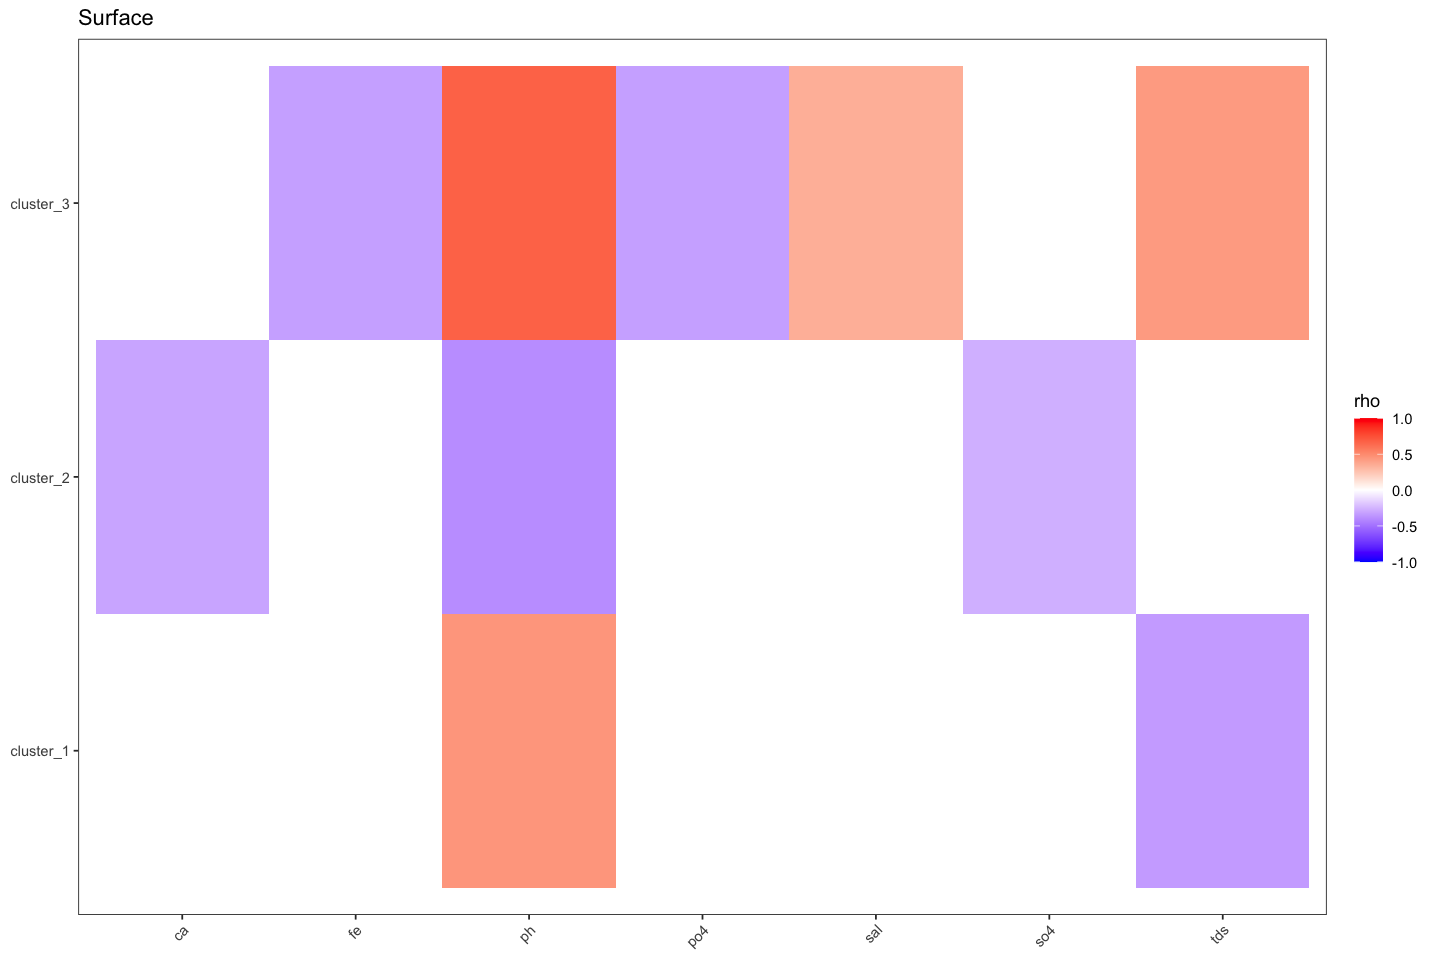

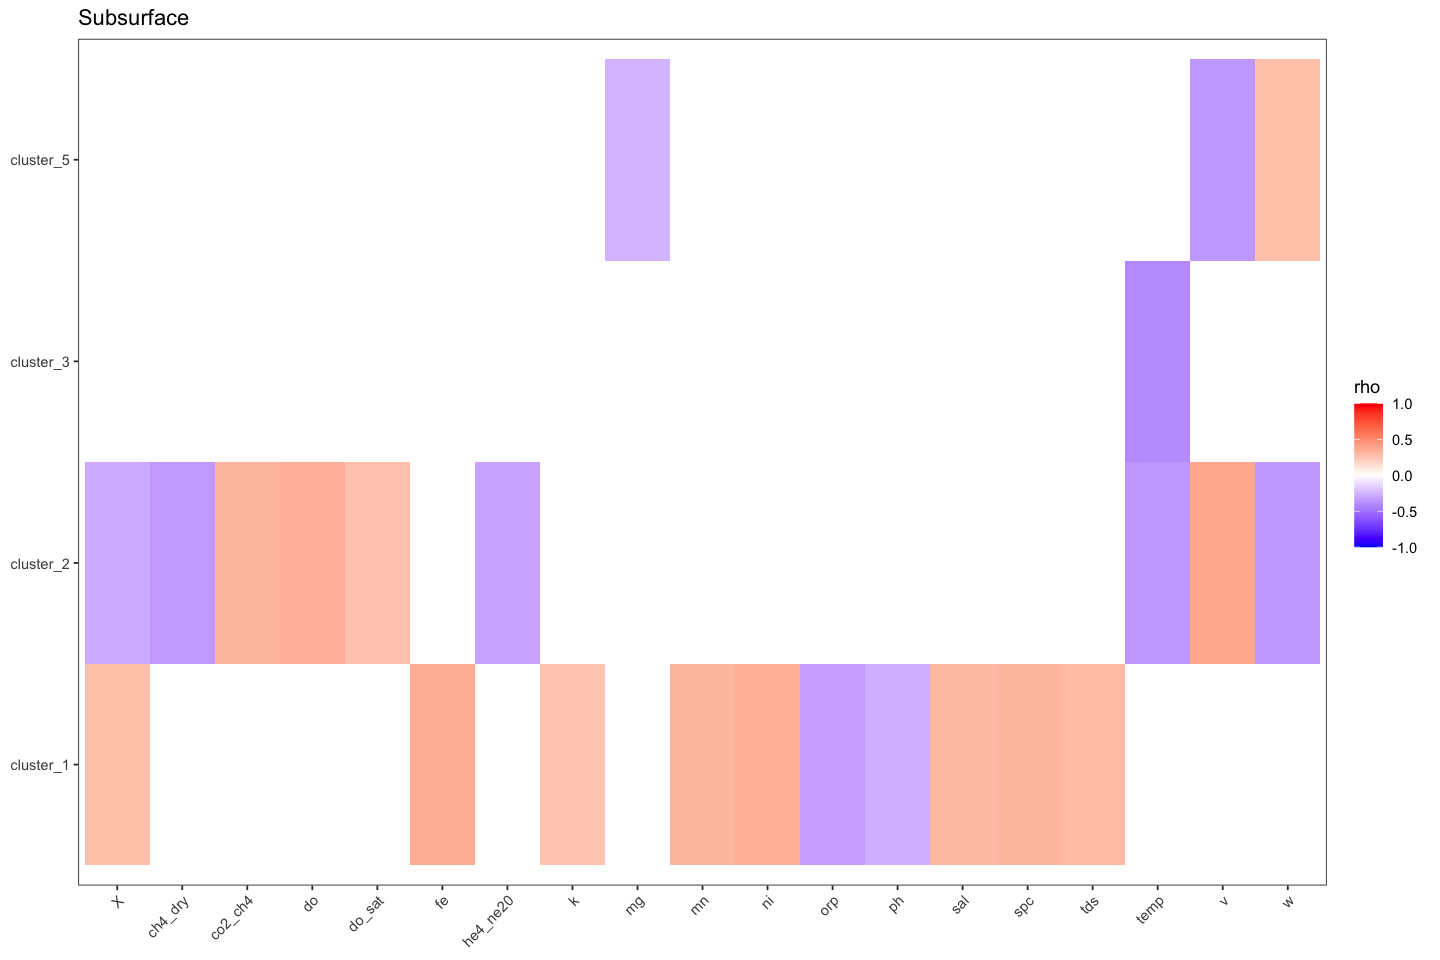

In [685]:
plot_heatmap(res_surface_filt, "Surface")
plot_heatmap(res_subsurface_filt, "Subsurface")

In [686]:
compute_cluster_sums <- function(physeq_obj, membership_table) {
  M <- get_gene_matrix(physeq_obj)

  membership_table <- membership_table %>%
    filter(gene %in% rownames(M))

  sum_list <- lapply(split(membership_table$gene, membership_table$cluster), function(gs) {
    colSums(M[gs, , drop = FALSE], na.rm = TRUE)
  })

  sum_df <- as.data.frame(sum_list)
  colnames(sum_df) <- paste0("cluster_", names(sum_list))
  sum_df$SampleID <- colnames(M)

  as_tibble(sum_df)
}

In [687]:
surf_sums <- compute_cluster_sums(phylo_rpo_surface_cfp, surf_clusters$membership_table)
sub_sums  <- compute_cluster_sums(phylo_rpo_subsurface_cfp, sub_clusters$membership_table)

In [688]:
compare_scores_vs_sums <- function(score_df, sum_df) {
  dat <- left_join(score_df, sum_df, by = "SampleID", suffix = c("_score", "_sum"))

  cl_score <- grep("^cluster_", names(score_df), value = TRUE)
  cl_sum   <- grep("^cluster_", names(sum_df), value = TRUE)
  cl_keep  <- intersect(cl_score, cl_sum)

  bind_rows(lapply(cl_keep, function(cl) {
    x <- dat[[cl]]
    y <- dat[[cl]]

    # because names collide after join if identical, rebuild directly
    x <- score_df[[cl]][match(dat$SampleID, score_df$SampleID)]
    y <- sum_df[[cl]][match(dat$SampleID, sum_df$SampleID)]

    ok <- is.finite(x) & is.finite(y)

    tibble(
      cluster = cl,
      spearman_rho = cor(x[ok], y[ok], method = "spearman"),
      pearson_r = cor(x[ok], y[ok], method = "pearson")
    )
  }))
}

In [689]:
surf_score_sum_cor <- compare_scores_vs_sums(surf_scores, surf_sums)
sub_score_sum_cor  <- compare_scores_vs_sums(sub_scores, sub_sums)

surf_score_sum_cor
sub_score_sum_cor

cluster,spearman_rho,pearson_r
<chr>,<dbl>,<dbl>
cluster_1,-0.98687834,-0.9881298
cluster_2,-0.05132466,-0.4414154
cluster_3,0.99123904,0.9912697


cluster,spearman_rho,pearson_r
<chr>,<dbl>,<dbl>
cluster_1,-0.9882901,-0.9896122
cluster_2,-0.9705390,-0.9638835
cluster_3,-0.6295156,-0.9986159
cluster_5,0.9855525,0.9935750


In [690]:
res_surface_sum <- correlate_clusters_env(
  surf_sums,
  env_surface,
  sample_col = "SampleID",
  min_n = 20
)

res_subsurface_sum <- correlate_clusters_env(
  sub_sums,
  env_subsurface,
  sample_col = "SampleID",
  min_n = 20
)

In [691]:
res_surface_sum_filt <- res_surface_sum %>%
  filter(is.finite(rho), abs(rho) >= 0.25, p_adj < 0.01)

res_subsurface_sum_filt <- res_subsurface_sum %>%
  filter(is.finite(rho), abs(rho) >= 0.25, p_adj < 0.01)

In [692]:
compare_env_results <- function(res_score, res_sum) {
  full_join(
    res_score %>% select(cluster, variable, rho_score = rho, p_adj_score = p_adj),
    res_sum   %>% select(cluster, variable, rho_sum   = rho, p_adj_sum   = p_adj),
    by = c("cluster", "variable")
  ) %>%
    mutate(
      same_sign = sign(rho_score) == sign(rho_sum),
      delta_rho = rho_score - rho_sum
    ) %>%
    arrange(cluster, variable)
}

In [693]:
surf_env_compare <- compare_env_results(res_surface_filt, res_surface_sum_filt)
sub_env_compare  <- compare_env_results(res_subsurface_filt, res_subsurface_sum_filt)

surf_env_compare
sub_env_compare

cluster,variable,rho_score,p_adj_score,rho_sum,p_adj_sum,same_sign,delta_rho
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
cluster_1,ph,0.4531215,9.259081e-30,-0.4343399,4.182998e-27,FALSE,0.887461311
cluster_1,tds,-0.3411674,1.219025e-08,0.3746827,1.819418e-10,FALSE,-0.715850197
cluster_2,ca,-0.3070707,7.148971e-04,0.3506342,5.510684e-05,FALSE,-0.657704876
cluster_2,ph,-0.3957086,3.845730e-22,-0.4242643,9.523284e-26,TRUE,0.028555711
cluster_2,so4,-0.2691769,3.260476e-03,NA,NA,NA,NA
cluster_2,tds,NA,NA,-0.5479340,5.525566e-24,NA,NA
cluster_3,fe,-0.3251731,4.745187e-03,-0.3182522,6.028132e-03,TRUE,-0.006920892
cluster_3,ph,0.6788930,3.168449e-79,0.6951185,1.335716e-84,TRUE,-0.016225544
cluster_3,po4,-0.3277009,1.148184e-06,-0.3495300,1.444685e-07,TRUE,0.021829167


cluster,variable,rho_score,p_adj_score,rho_sum,p_adj_sum,same_sign,delta_rho
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
cluster_1,X,0.2729624,6.259258e-04,-0.2896633,2.715428e-04,FALSE,0.562625686
cluster_1,ca,NA,NA,-0.2615179,2.217086e-05,NA,NA
cluster_1,fe,0.3551657,1.365808e-05,-0.3635848,8.488404e-06,FALSE,0.718750522
cluster_1,k,0.2519267,3.396123e-05,-0.2684192,8.488404e-06,FALSE,0.520345855
cluster_1,mn,0.3155859,4.228783e-05,-0.3158750,3.682254e-05,FALSE,0.631460892
cluster_1,ni,0.3434276,1.650608e-04,-0.3258094,3.338430e-04,FALSE,0.669236964
cluster_1,orp,-0.3327155,1.332796e-05,0.3340466,8.579314e-06,FALSE,-0.666762066
cluster_1,ph,-0.2673676,1.160614e-06,NA,NA,NA,NA
cluster_1,sal,0.3025944,7.810729e-07,-0.3261167,5.222807e-08,FALSE,0.628711154


In [694]:
orient_scores_to_sum <- function(score_df, sum_df) {
  out <- score_df
  
  cl_cols <- intersect(
    grep("^cluster_", names(score_df), value = TRUE),
    grep("^cluster_", names(sum_df), value = TRUE)
  )
  
  for (cl in cl_cols) {
    x <- score_df[[cl]]
    y <- sum_df[[cl]]
    ok <- is.finite(x) & is.finite(y)
    
    if (sum(ok) > 3) {
      r <- cor(x[ok], y[ok], method = "spearman")
      if (is.finite(r) && r < 0) {
        out[[cl]] <- -out[[cl]]
      }
    }
  }
  
  out
}

sub_scores_oriented <- orient_scores_to_sum(sub_scores, sub_sums)
surf_scores_oriented <- orient_scores_to_sum(surf_scores, surf_sums)

In [695]:
plot_df <- sub_scores_oriented %>%
  left_join(env_subsurface, by = "SampleID")

In [696]:
plot_scatter_env <- function(df, x_col, y_col, x_label, y_label, filename,
                              log_x = FALSE, log_y = FALSE,
                              lm_color = "darkgray", lm_linewidth = 0.6,
                              width = 12, height = 8) {
  x <- if (log_x) log10(df[[x_col]]) else df[[x_col]]
  y <- if (log_y) log10(df[[y_col]]) else df[[y_col]]
  plot_data <- data.frame(x = x, y = y)

  print(cor.test(x, y, method = "spearman"))

  p <- ggplot(plot_data, aes(x = x, y = y)) +
    geom_point(aes(fill = x), color = "black", shape = 21, size = 5, alpha = 0.8) +
geom_smooth(method = "lm", color = lm_color, linewidth = lm_linewidth, se = TRUE) +
    theme_glab(base_size = 22) +
    labs(x = x_label, y = y_label, fill = x_label)

  ggsave(filename, plot = p, width = width, height = height)
  p
}

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 8218414, p-value = 5.608e-09
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
-0.311622 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 77 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 77 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 77 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 77 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 1409696, p-value = 0.0001507
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.2729624 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 224 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 224 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 224 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 224 rows containing missing values or values outside the scale range
(`geom_point()`).”


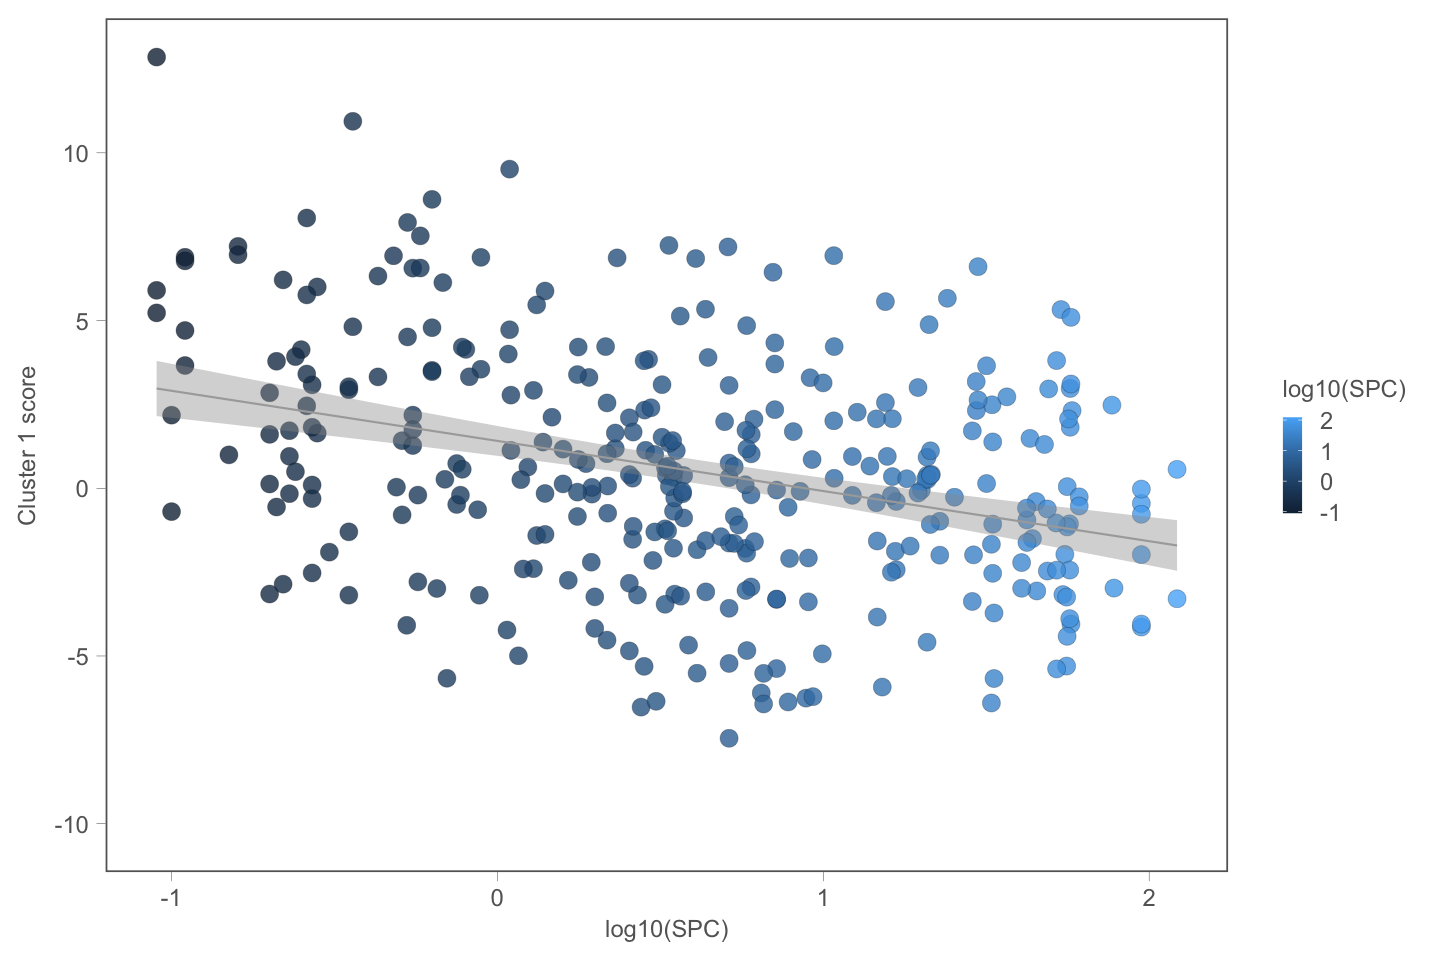

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 6437830, p-value = 2.385e-13
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3587382 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


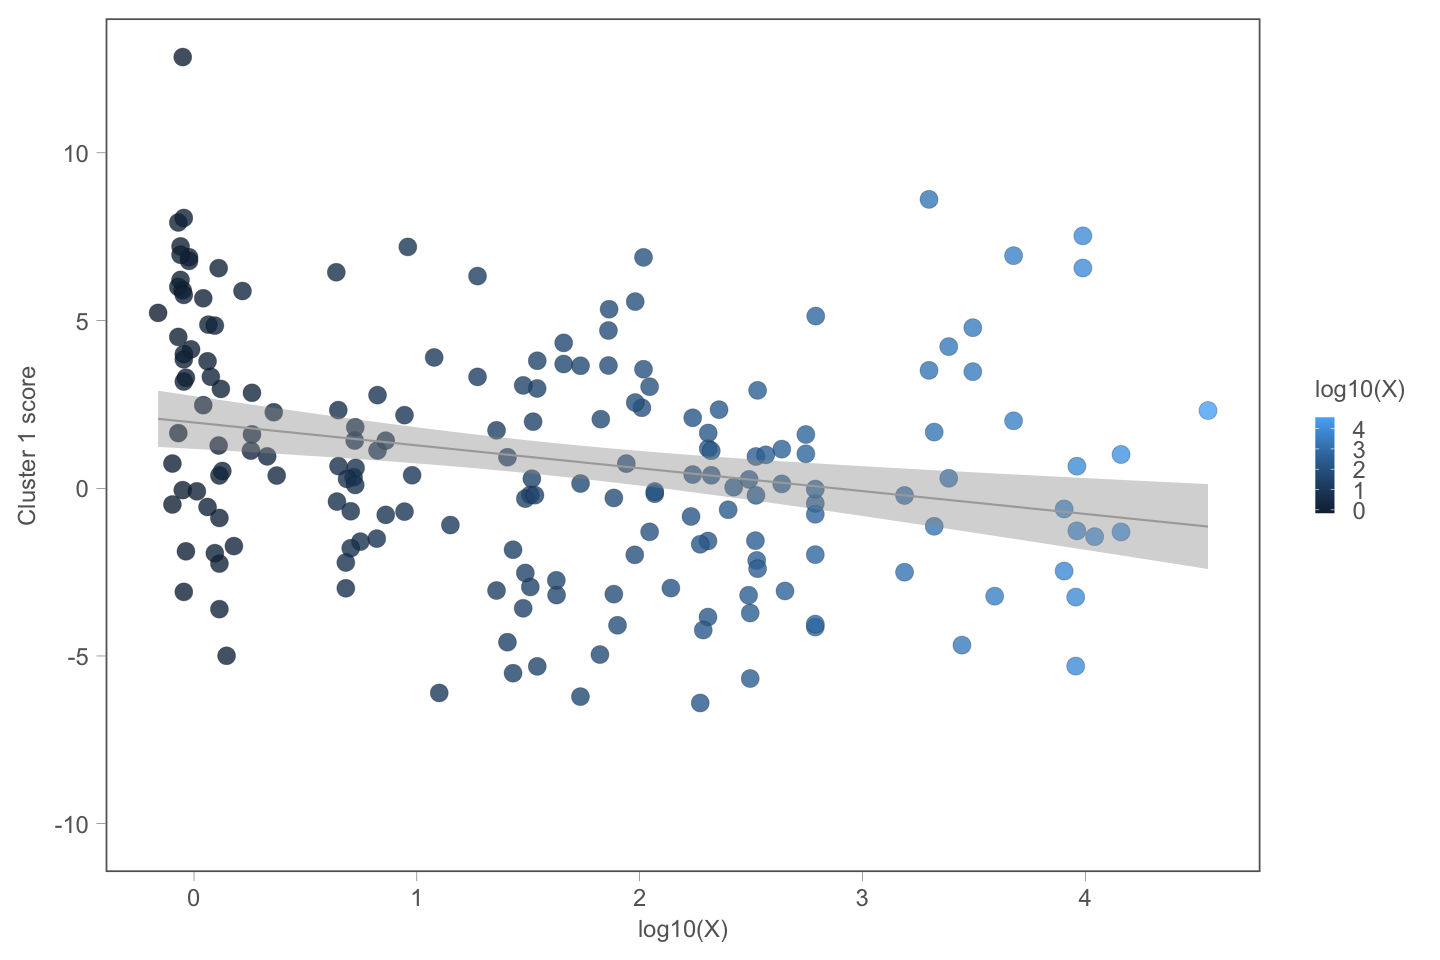

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 508789, p-value = 2.156e-06
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3561623 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 244 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 244 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_point()`).”


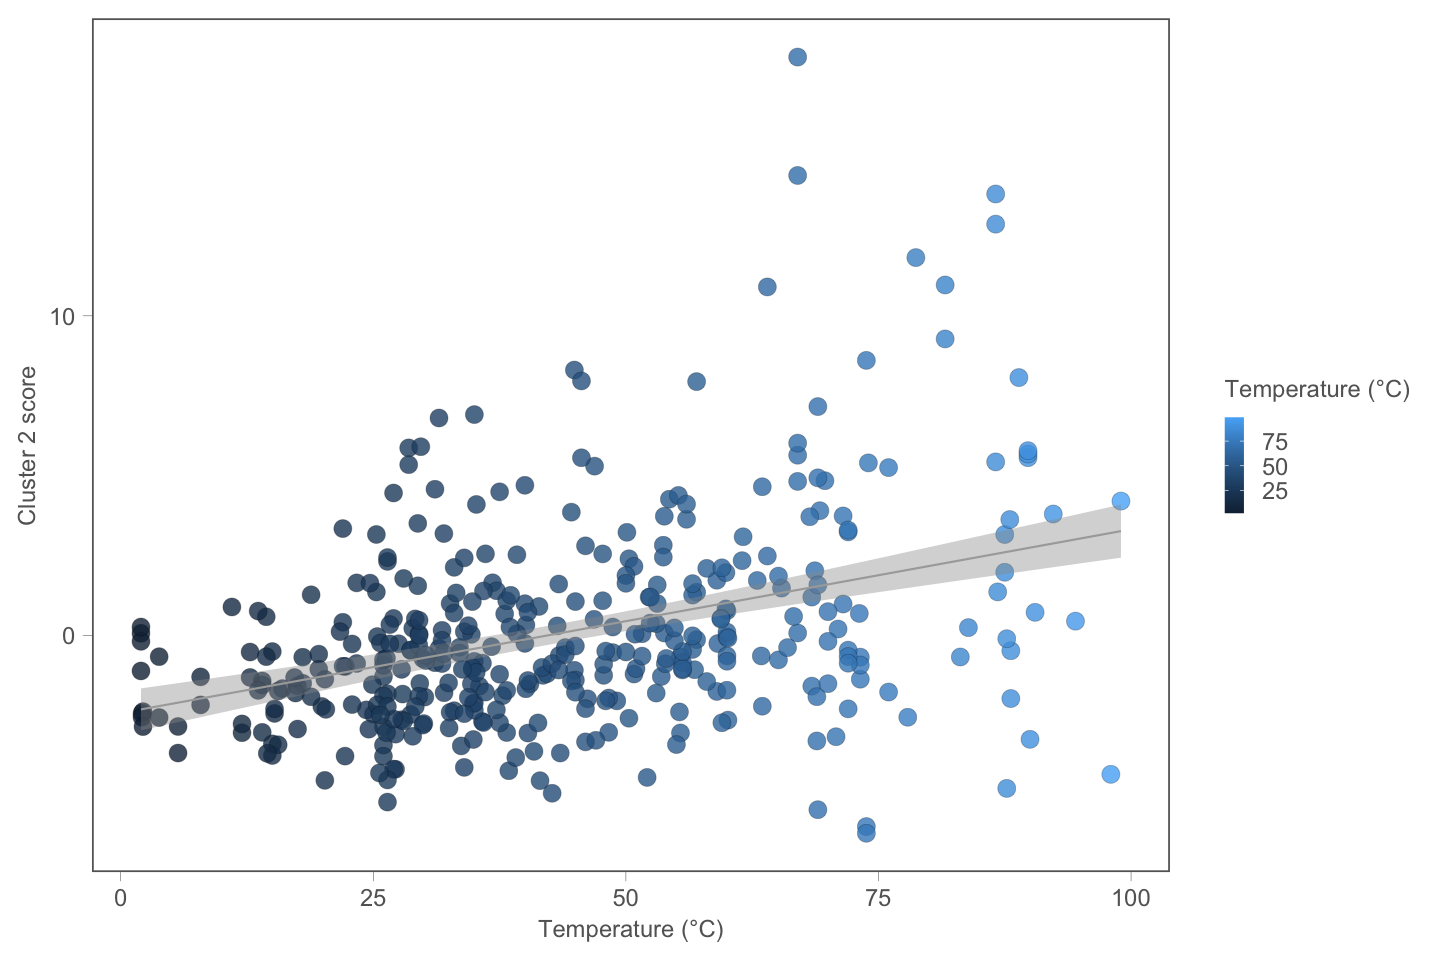

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 834410, p-value = 8.084e-06
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3142949 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 218 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 218 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 218 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 218 rows containing missing values or values outside the scale range
(`geom_point()`).”


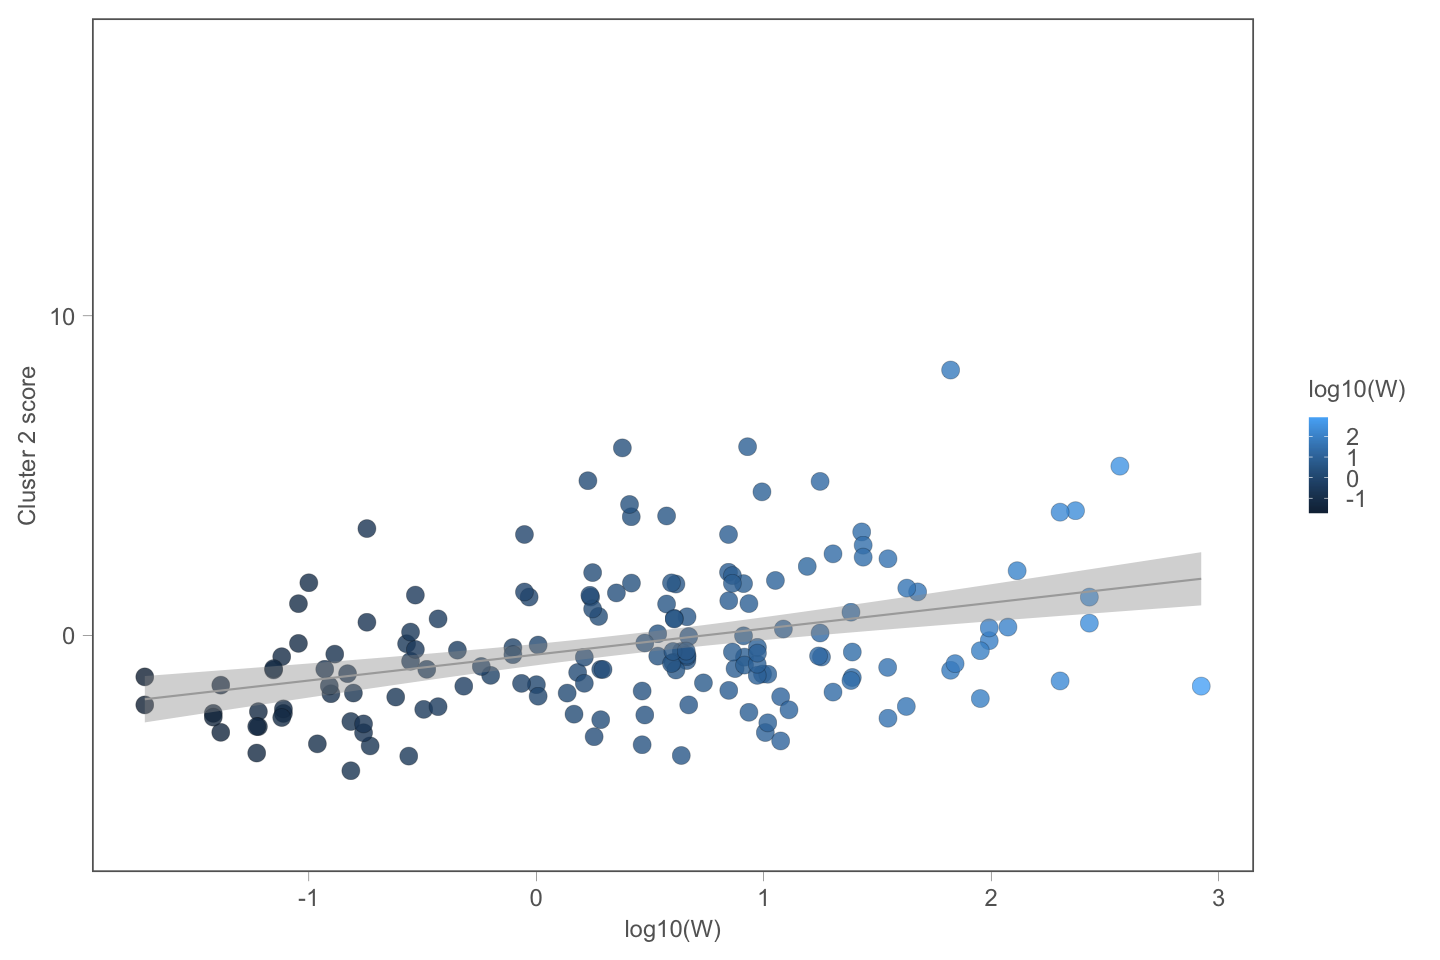

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 114333, p-value = 0.0002677
alternative hypothesis: true rho is not equal to 0
sample estimates:
     rho 
0.353508 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 314 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 310 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 314 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 310 rows containing missing values or values outside the scale range
(`geom_point()`).”


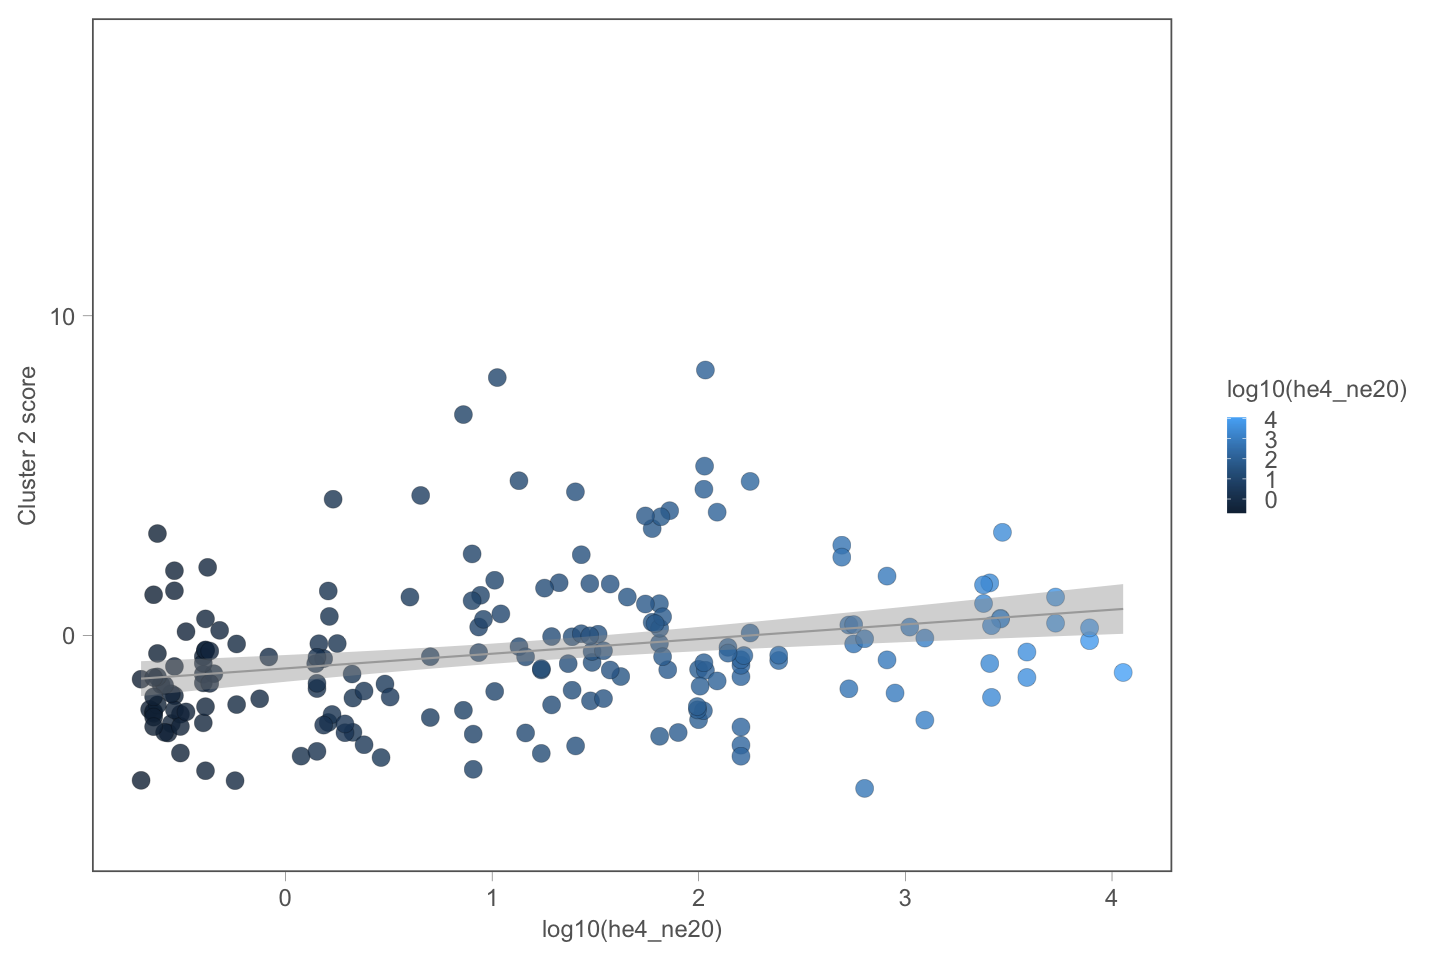

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 5884465, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
     rho 
0.413858 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


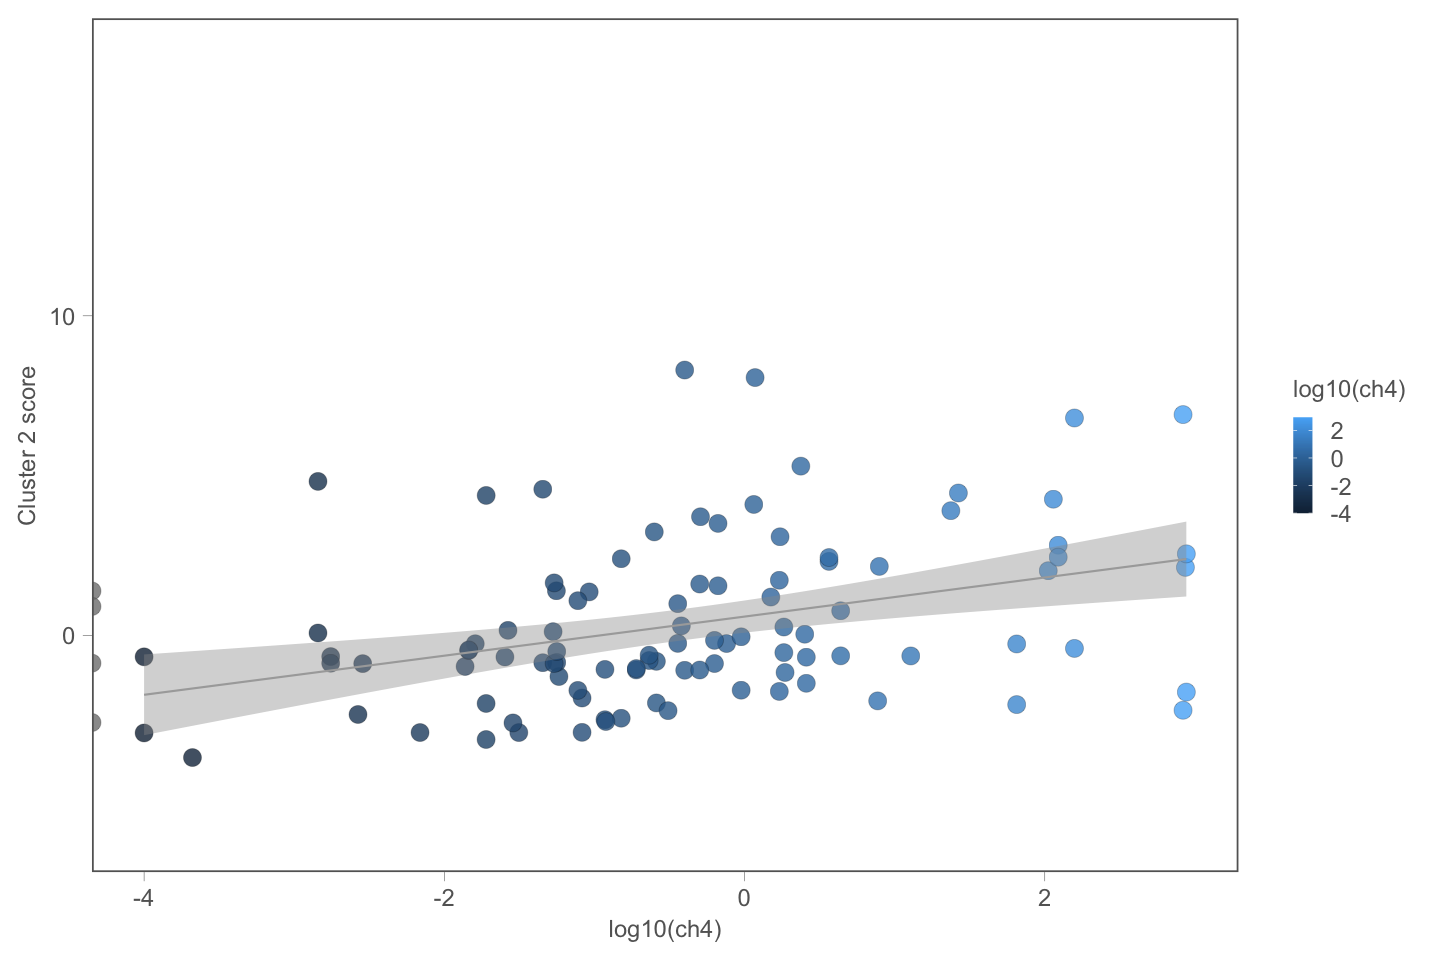

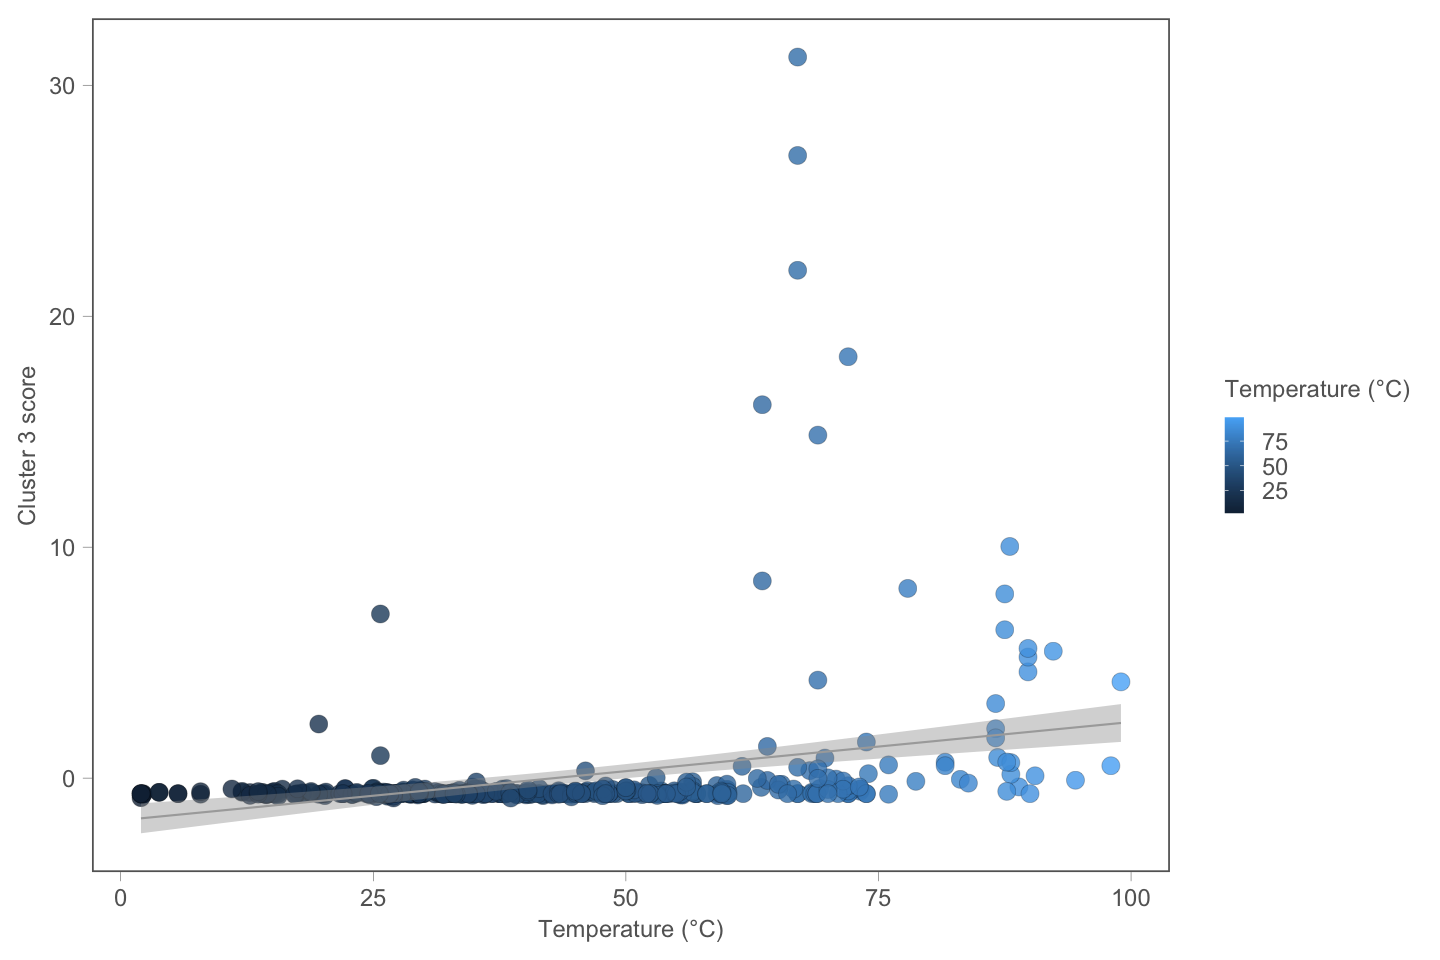

In [697]:
plot_scatter_env(plot_df, "spc",      "cluster_1", "log10(SPC)",       "Cluster 1 score", "cluster_1-spc.svg",      log_x = TRUE)
plot_scatter_env(plot_df, "X",        "cluster_1", "log10(X)",         "Cluster 1 score", "cluster_1-X.svg",        log_x = TRUE)
plot_scatter_env(plot_df, "temp",     "cluster_2", "Temperature (°C)", "Cluster 2 score", "cluster_2-temp.svg",     height = 4)
plot_scatter_env(plot_df, "w",        "cluster_2", "log10(W)",         "Cluster 2 score", "cluster_2-W.svg",        log_x = TRUE)
plot_scatter_env(plot_df, "he4_ne20", "cluster_2", "log10(he4_ne20)",  "Cluster 2 score", "cluster_2-he4_ne20.svg", log_x = TRUE, height = 4)
plot_scatter_env(plot_df, "ch4_dry",  "cluster_2", "log10(ch4)",       "Cluster 2 score", "cluster_2-ch4.svg",      log_x = TRUE)
plot_scatter_env(plot_df, "temp",     "cluster_3", "Temperature (°C)", "Cluster 3 score", "cluster_3-temp.svg")

In [698]:
sub_score_sum_cor  <- compare_scores_vs_sums(sub_scores_oriented, sub_sums)

sub_score_sum_cor

cluster,spearman_rho,pearson_r
<chr>,<dbl>,<dbl>
cluster_1,0.9882901,0.9896122
cluster_2,0.9705390,0.9638835
cluster_3,0.6295156,0.9986159
cluster_5,0.9855525,0.9935750


In [699]:
res_subsurface <- correlate_clusters_env(
  sub_scores_oriented,
  env_subsurface,
  sample_col = "SampleID",
  min_n = 20
)

In [700]:
res_subsurface_filt <- res_subsurface %>%
  filter(is.finite(rho), abs(rho) >= 0.25, p_adj < 0.01)

In [701]:
sub_env_compare  <- compare_env_results(res_subsurface_filt, res_subsurface_sum_filt)

sub_env_compare

cluster,variable,rho_score,p_adj_score,rho_sum,p_adj_sum,same_sign,delta_rho
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
cluster_1,X,-0.2729624,6.259258e-04,-0.2896633,2.715428e-04,TRUE,0.0167009710
cluster_1,ca,NA,NA,-0.2615179,2.217086e-05,NA,NA
cluster_1,fe,-0.3551657,1.365808e-05,-0.3635848,8.488404e-06,TRUE,0.0084190712
cluster_1,k,-0.2519267,3.396123e-05,-0.2684192,8.488404e-06,TRUE,0.0164924631
cluster_1,mn,-0.3155859,4.228783e-05,-0.3158750,3.682254e-05,TRUE,0.0002890685
cluster_1,ni,-0.3434276,1.650608e-04,-0.3258094,3.338430e-04,TRUE,-0.0176181466
cluster_1,orp,0.3327155,1.332796e-05,0.3340466,8.579314e-06,TRUE,-0.0013310421
cluster_1,ph,0.2673676,1.160614e-06,NA,NA,NA,NA
cluster_1,sal,-0.3025944,7.810729e-07,-0.3261167,5.222807e-08,TRUE,0.0235223290


In [702]:
plot_df_sum <- sub_sums %>%
  left_join(env_subsurface, by = "SampleID")

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 928475, p-value = 1.112e-06
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3340466 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 209 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 209 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 209 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 209 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 619392, p-value = 8.065e-05
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.3258094 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 271 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 271 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 271 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 271 rows containing missing values or values outside the scale range
(`geom_point()`).”


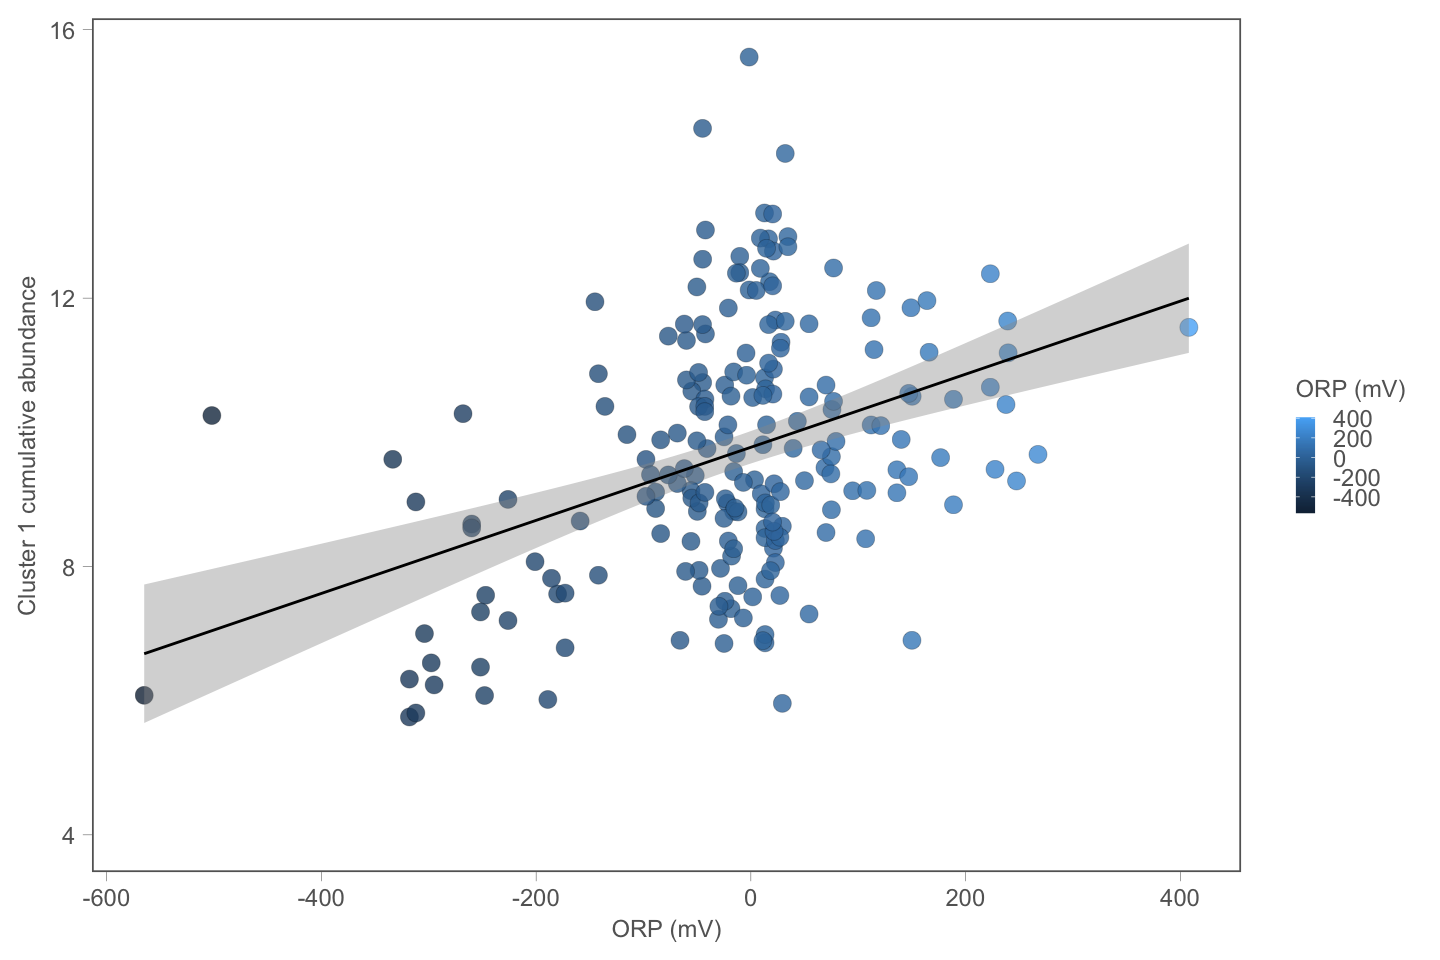

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 881289, p-value = 9.944e-05
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.2757712 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 218 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 218 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 218 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 218 rows containing missing values or values outside the scale range
(`geom_point()`).”


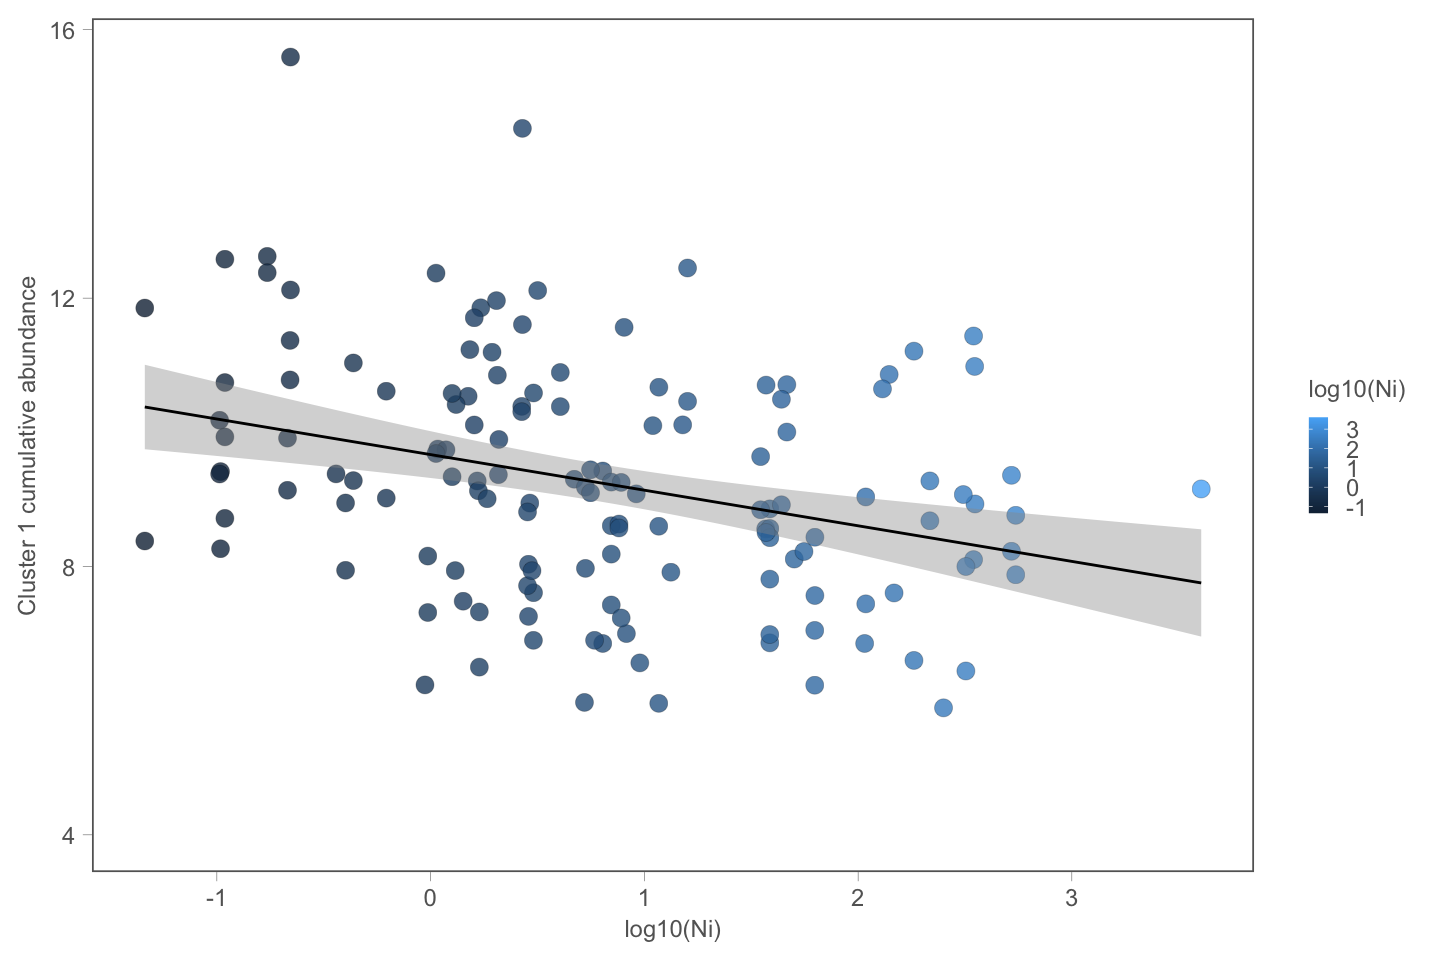

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 125334, p-value = 0.002974
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.2913024 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 314 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 310 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 314 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 310 rows containing missing values or values outside the scale range
(`geom_point()`).”


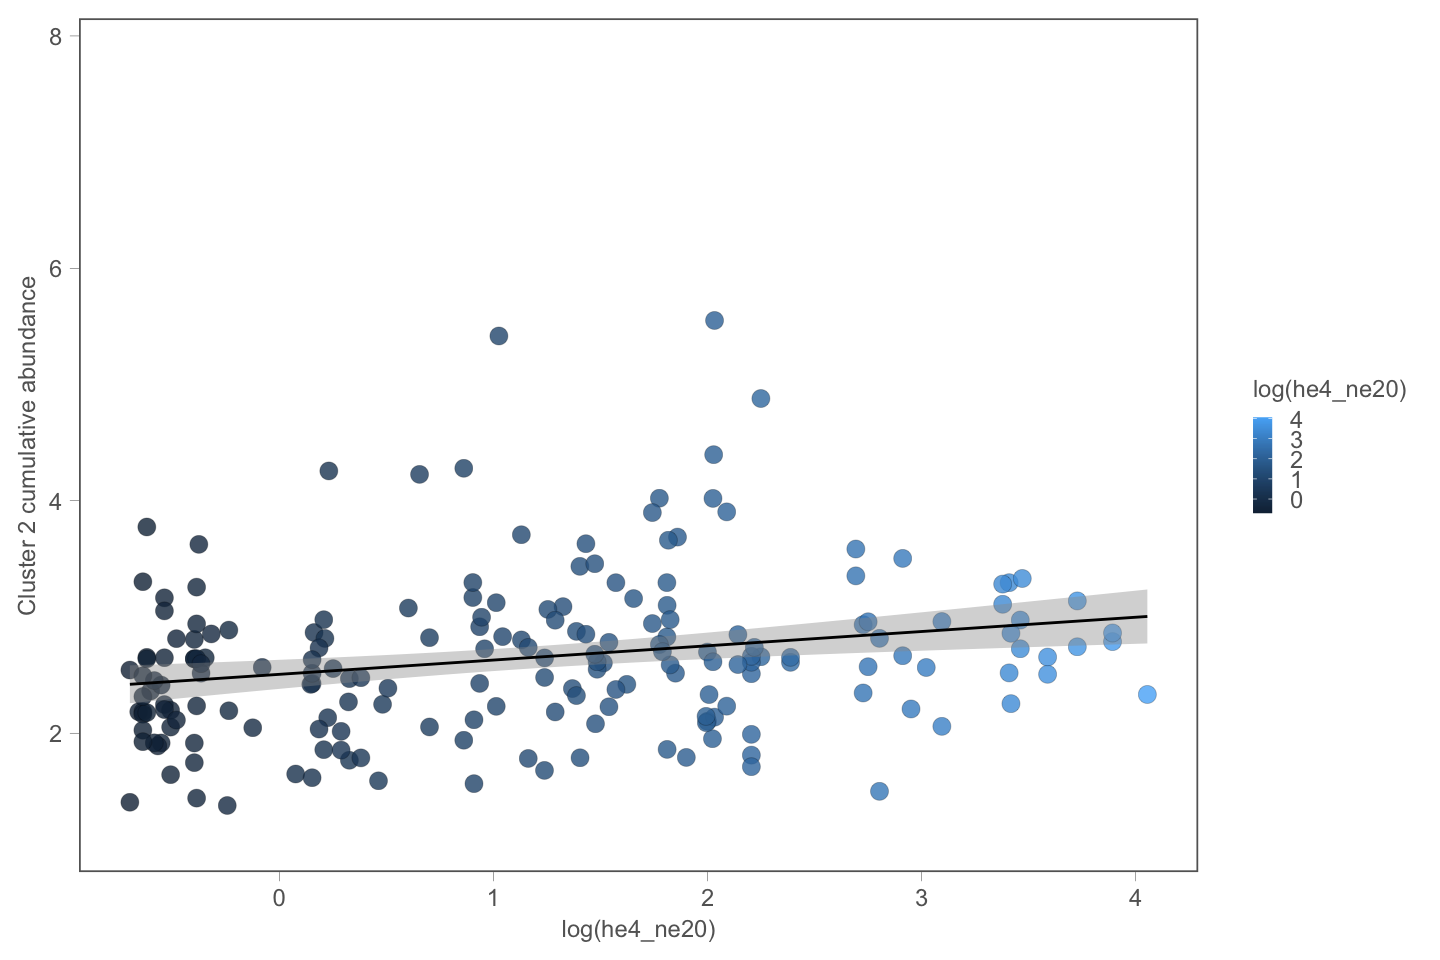

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 559896, p-value = 0.0001263
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.2914903 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 244 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 244 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_point()`).”


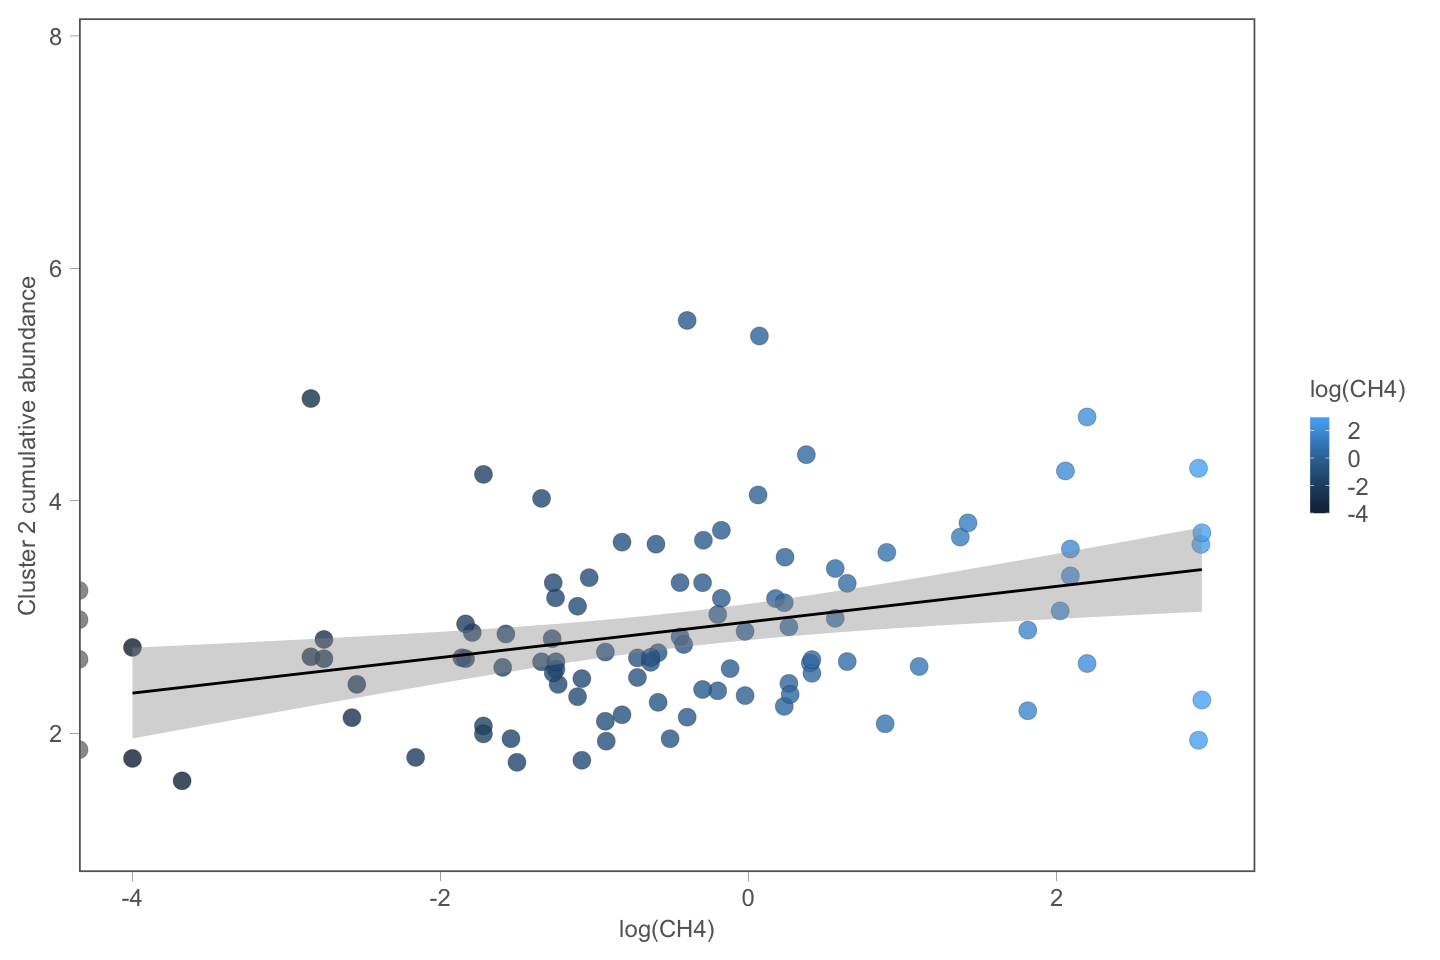

Warning message in cor.test.default(x, y, method = "spearman"):
“Impossible de calculer la p-value exacte avec des ex-aequos”



	Spearman's rank correlation rho

data:  x and y
S = 6322835, p-value = 3.539e-14
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3701927 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 166 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 166 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


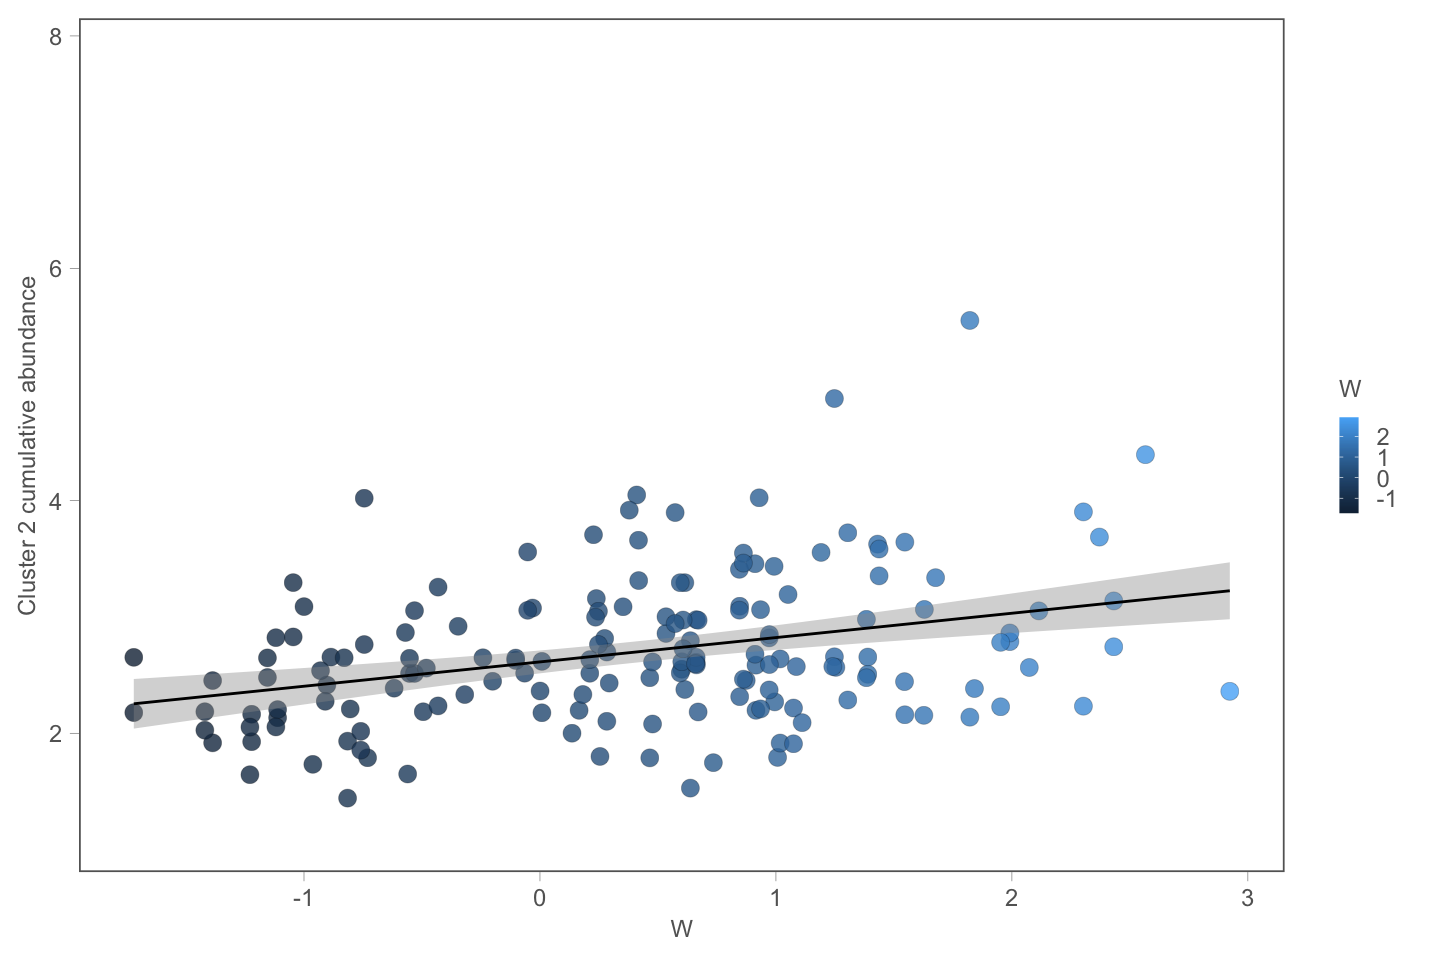

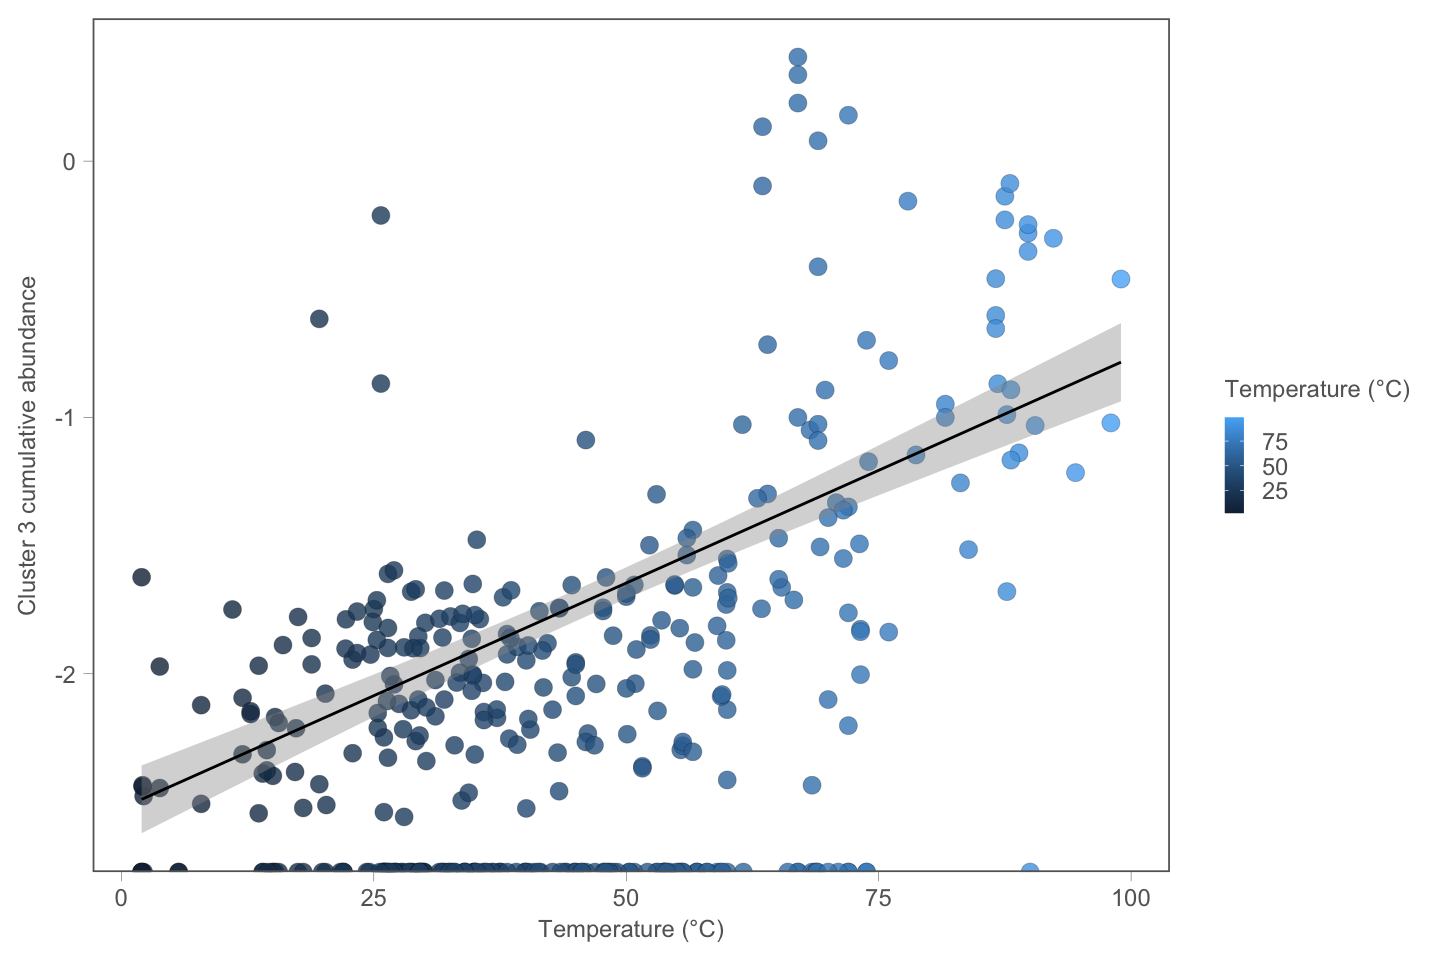

In [703]:
plot_scatter_env(plot_df_sum, "orp",      "cluster_1", "ORP (mV)",         "Cluster 1 cumulative abundance", "Sum_cluster_1-orp.svg",      lm_color = "black", lm_linewidth = 0.8)
plot_scatter_env(plot_df_sum, "ni",       "cluster_1", "log10(Ni)",        "Cluster 1 cumulative abundance", "Sum_cluster_1-Ni.svg",       log_x = TRUE, lm_color = "black", lm_linewidth = 0.8)
plot_scatter_env(plot_df_sum, "he4_ne20", "cluster_2", "log(he4_ne20)",    "Cluster 2 cumulative abundance", "Sum_cluster_2-he4_ne20.svg", log_x = TRUE, lm_color = "black", lm_linewidth = 0.8)
plot_scatter_env(plot_df_sum, "ch4_dry",  "cluster_2", "log(CH4)",         "Cluster 2 cumulative abundance", "Sum_cluster_2-CH4.svg",      log_x = TRUE, lm_color = "black", lm_linewidth = 0.8)
plot_scatter_env(plot_df_sum, "w",        "cluster_2", "W",                "Cluster 2 cumulative abundance", "Sum_cluster_2-W.svg",        log_x = TRUE, lm_color = "black", lm_linewidth = 0.8)
plot_scatter_env(plot_df_sum, "temp",     "cluster_3", "Temperature (°C)", "Cluster 3 cumulative abundance", "Sum_cluster_3-temp.svg",     log_y = TRUE, lm_color = "black", lm_linewidth = 0.8)

In [704]:
env_surface_num <- env_surface %>%
  select(SampleID, where(is.numeric))

env_subsurface_num <- env_subsurface %>%
  select(SampleID, where(is.numeric))


res_surface <- correlate_clusters_env(
  surf_scores,
  env_surface_num,
  sample_col = "SampleID",
  min_n = 20
)

res_subsurface <- correlate_clusters_env(
  sub_scores,
  env_subsurface_num,
  sample_col = "SampleID",
  min_n = 20
)

res_surface_sum <- correlate_clusters_env(
  surf_sums,
  env_surface_num,
  sample_col = "SampleID",
  min_n = 20
)

res_subsurface_sum <- correlate_clusters_env(
  sub_sums,
  env_subsurface_num,
  sample_col = "SampleID",
  min_n = 20
)

# effect-size filter; adjust if needed
rho_cut_env <- 0.25
padj_cut_env <- 0.01

res_surface_filt <- res_surface %>%
  filter(is.finite(rho), abs(rho) >= rho_cut_env, p_adj < padj_cut_env)

res_subsurface_filt <- res_subsurface %>%
  filter(is.finite(rho), abs(rho) >= rho_cut_env, p_adj < padj_cut_env)

res_surface_sum_filt <- res_surface_sum %>%
  filter(is.finite(rho), abs(rho) >= rho_cut_env, p_adj < padj_cut_env)

res_subsurface_sum_filt <- res_subsurface_sum %>%
  filter(is.finite(rho), abs(rho) >= rho_cut_env, p_adj < padj_cut_env)

rho_star <- 0.42
core_stats <- sweep_stats %>%
  filter(abs(rho - rho_star) < 1e-9) %>%
  select(environment, rho, nodes, edges, density, components, giant_frac, modularity, mean_degree, transitivity)

surface_cluster_sizes <- surf_clusters$membership_table %>%
  count(cluster, name = "cluster_size") %>%
  arrange(desc(cluster_size), cluster)

subsurface_cluster_sizes <- sub_clusters$membership_table %>%
  count(cluster, name = "cluster_size") %>%
  arrange(desc(cluster_size), cluster)

top_surface <- res_surface_filt %>%
  arrange(desc(abs(rho)), p_adj) %>%
  select(cluster, variable, n, rho, p_adj) %>%
  head(15)

top_subsurface <- res_subsurface_filt %>%
  arrange(desc(abs(rho)), p_adj) %>%
  select(cluster, variable, n, rho, p_adj) %>%
  head(15)

In [705]:
top_surface_sum <- res_surface_sum_filt %>%
  arrange(desc(abs(rho)), p_adj) %>%
  select(cluster, variable, n, rho, p_adj) %>%
  head(15)

top_subsurface_sum <- res_subsurface_sum_filt %>%
  arrange(desc(abs(rho)), p_adj) %>%
  select(cluster, variable, n, rho, p_adj) %>%
  head(15)

In [706]:
surface_variable_partition_sum <- res_surface_sum_filt %>%
  group_by(variable) %>%
  summarise(
    n_clusters = n(),
    rho_min = min(rho),
    rho_max = max(rho),
    rho_range = rho_max - rho_min,
    .groups = "drop"
  ) %>%
  arrange(desc(n_clusters), desc(rho_range))

subsurface_variable_partition_sum <- res_subsurface_sum_filt %>%
  group_by(variable) %>%
  summarise(
    n_clusters = n(),
    rho_min = min(rho),
    rho_max = max(rho),
    rho_range = rho_max - rho_min,
    .groups = "drop"
  ) %>%
  arrange(desc(n_clusters), desc(rho_range))
surface_variable_partition <- res_surface_filt %>%
  group_by(variable) %>%
  summarise(
    n_clusters = n(),
    rho_min = min(rho),
    rho_max = max(rho),
    rho_range = rho_max - rho_min,
    .groups = "drop"
  ) %>%
  arrange(desc(n_clusters), desc(rho_range))

subsurface_variable_partition <- res_subsurface_filt %>%
  group_by(variable) %>%
  summarise(
    n_clusters = n(),
    rho_min = min(rho),
    rho_max = max(rho),
    rho_range = rho_max - rho_min,
    .groups = "drop"
  ) %>%
  arrange(desc(n_clusters), desc(rho_range))

In [707]:
surface_cluster_variable_map <- res_surface_filt %>%
  arrange(cluster, desc(abs(rho)), variable) %>%
  select(cluster, variable, rho, p_adj, n)

subsurface_cluster_variable_map <- res_subsurface_filt %>%
  arrange(cluster, desc(abs(rho)), variable) %>%
  select(cluster, variable, rho, p_adj, n)

surface_cluster_variable_map_sum <- res_surface_sum_filt %>%
  arrange(cluster, desc(abs(rho)), variable) %>%
  select(cluster, variable, rho, p_adj, n)

subsurface_cluster_variable_map_sum <- res_subsurface_sum_filt %>%
  arrange(cluster, desc(abs(rho)), variable) %>%
  select(cluster, variable, rho, p_adj, n)

In [708]:
cat("\n==============================\n")
cat("CORE NETWORK STATS AT rho = ", rho_star, "\n", sep = "")
cat("==============================\n")
print(core_stats, n = Inf)

cat("\n==============================\n")
cat("SURFACE CLUSTER SIZES\n")
cat("==============================\n")
print(surface_cluster_sizes, n = Inf)

cat("\n==============================\n")
cat("SUBSURFACE CLUSTER SIZES\n")
cat("==============================\n")
print(subsurface_cluster_sizes, n = Inf)

cat("\n==============================\n")
cat("TOP SURFACE CLUSTER-ENV ASSOCIATIONS (SCORES)\n")
cat("==============================\n")
print(top_surface, n = Inf)

cat("\n==============================\n")
cat("TOP SUBSURFACE CLUSTER-ENV ASSOCIATIONS (SCORES)\n")
cat("==============================\n")
print(top_subsurface, n = Inf)

cat("\n==============================\n")
cat("TOP SURFACE CLUSTER-ENV ASSOCIATIONS (SUMS)\n")
cat("==============================\n")
print(top_surface_sum, n = Inf)

cat("\n==============================\n")
cat("TOP SUBSURFACE CLUSTER-ENV ASSOCIATIONS (SUMS)\n")
cat("==============================\n")
print(top_subsurface_sum, n = Inf)

cat("\n==============================\n")
cat("SURFACE VARIABLE PARTITION SUMMARY (SCORES)\n")
cat("==============================\n")
print(surface_variable_partition, n = Inf)

cat("\n==============================\n")
cat("SUBSURFACE VARIABLE PARTITION SUMMARY (SCORES)\n")
cat("==============================\n")
print(subsurface_variable_partition, n = Inf)

cat("\n==============================\n")
cat("SURFACE VARIABLE PARTITION SUMMARY (SUMS)\n")
cat("==============================\n")
print(surface_variable_partition_sum, n = Inf)

cat("\n==============================\n")
cat("SUBSURFACE VARIABLE PARTITION SUMMARY (SUMS)\n")
cat("==============================\n")
print(subsurface_variable_partition_sum, n = Inf)

cat("\n==============================\n")
cat("SURFACE CLUSTER-VARIABLE MAP (SCORES)\n")
cat("==============================\n")
print(surface_cluster_variable_map, n = Inf)

cat("\n==============================\n")
cat("SUBSURFACE CLUSTER-VARIABLE MAP (SCORES)\n")
cat("==============================\n")
print(subsurface_cluster_variable_map, n = Inf)

cat("\n==============================\n")
cat("SURFACE CLUSTER-VARIABLE MAP (SUMS)\n")
cat("==============================\n")
print(surface_cluster_variable_map_sum, n = Inf)

cat("\n==============================\n")
cat("SUBSURFACE CLUSTER-VARIABLE MAP (SUMS)\n")
cat("==============================\n")
print(subsurface_cluster_variable_map_sum, n = Inf)


CORE NETWORK STATS AT rho = 0.42


# A tibble: 2 × 10
  environment   rho nodes edges density components giant_frac modularity
  <fct>       <dbl> <dbl> <dbl>   <dbl>      <dbl>      <dbl>      <dbl>
1 surface      0.42    89  1011   0.258          2      0.955      0.328
2 subsurface   0.42   100   584   0.118          4      0.93       0.615
# ℹ 2 more variables: mean_degree <dbl>, transitivity <dbl>

SURFACE CLUSTER SIZES
# A tibble: 3 × 2
  cluster cluster_size
    <int>        <int>
1       2           42
2       1           38
3       3            3

SUBSURFACE CLUSTER SIZES
# A tibble: 4 × 2
  cluster cluster_size
    <int>        <int>
1       1           38
2       2           30
3       3           21
4       5            3

TOP SURFACE CLUSTER-ENV ASSOCIATIONS (SCORES)
# A tibble: 10 × 5
   cluster   variable     n    rho    p_adj
   <chr>     <chr>    <int>  <dbl>    <dbl>
 1 cluster_3 ph         587  0.679 3.17e-79
 2 cluster_1 ph         587  0.453 9.26e-30
 3 cluster_3 tds        301  0.430 5.48e-14
 4 cl

In [709]:
# Check cluster cooccurrence to see if they suggest functional layering or environmental partitioning 
sub_cluster_sums_only <- sub_sums %>%
  select(SampleID, starts_with("cluster_"))

cluster_sum_cor <- cor(
  sub_cluster_sums_only %>% select(-SampleID),
  method = "spearman",
  use = "pairwise.complete.obs"
)

cluster_sum_cor

,cluster_1,cluster_2,cluster_3,cluster_5
cluster_1,1.00000000,-0.04178052,0.13285141,0.25807066
cluster_2,-0.04178052,1.00000000,0.34823897,0.12645750
cluster_3,0.13285141,0.34823897,1.00000000,0.01807238
cluster_5,0.25807066,0.12645750,0.01807238,1.00000000


In [710]:
sub_cluster_scores_only <- sub_scores %>%
  select(SampleID, starts_with("cluster_"))

cluster_score_cor <- cor(
  sub_cluster_scores_only %>% select(-SampleID),
  method = "spearman",
  use = "pairwise.complete.obs"
)

cluster_score_cor

,cluster_1,cluster_2,cluster_3,cluster_5
cluster_1,1.00000000,-0.1650823,-0.054150838,-0.295277406
cluster_2,-0.16508235,1.0000000,0.252439427,-0.103580361
cluster_3,-0.05415084,0.2524394,1.000000000,0.006657391
cluster_5,-0.29527741,-0.1035804,0.006657391,1.000000000


In [711]:
pairwise_cluster_assoc <- function(df) {
  cl_cols <- grep("^cluster_", names(df), value = TRUE)
  pairs <- combn(cl_cols, 2, simplify = FALSE)
  
  bind_rows(lapply(pairs, function(p) {
    x <- df[[p[1]]]
    y <- df[[p[2]]]
    ok <- is.finite(x) & is.finite(y)
    
    ct <- cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)
    
    tibble(
      cluster_1 = p[1],
      cluster_2 = p[2],
      n = sum(ok),
      rho = unname(ct$estimate),
      p = ct$p.value
    )
  })) %>%
    mutate(p_adj = p.adjust(p, method = "BH")) %>%
    arrange(desc(abs(rho)))
}

sub_cluster_sum_assoc <- pairwise_cluster_assoc(sub_sums)
sub_cluster_score_assoc <- pairwise_cluster_assoc(sub_scores)

sub_cluster_sum_assoc
sub_cluster_score_assoc

cluster_1,cluster_2,n,rho,p,p_adj
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
cluster_2,cluster_3,412,0.34823897,3.438790e-13,2.063274e-12
cluster_1,cluster_5,412,0.25807066,1.080700e-07,3.242100e-07
cluster_1,cluster_3,412,0.13285141,6.926122e-03,1.385224e-02
cluster_2,cluster_5,412,0.12645750,1.018952e-02,1.528428e-02
cluster_1,cluster_2,412,-0.04178052,3.976393e-01,4.771672e-01
cluster_3,cluster_5,412,0.01807238,7.145556e-01,7.145556e-01


cluster_1,cluster_2,n,rho,p,p_adj
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
cluster_1,cluster_5,412,-0.295277406,9.834278e-10,5.900567e-09
cluster_2,cluster_3,412,0.252439427,2.072325e-07,6.216976e-07
cluster_1,cluster_2,412,-0.165082347,7.689618e-04,1.537924e-03
cluster_2,cluster_5,412,-0.103580361,3.557780e-02,5.336669e-02
cluster_1,cluster_3,412,-0.054150838,2.728131e-01,3.273757e-01
cluster_3,cluster_5,412,0.006657391,8.928323e-01,8.928323e-01


In [1112]:
save.image()